# Phase 2 — NLP Pipeline
**Text Mining of Airbnb Reviews for Customer Experience Insights and Rating Prediction**

| Stage | Method |
|---|---|
| Sampling | Short-review filter (< 10 words) → two-stage (listing→review) per-city fixed draw → English filter |
| Text Preprocessing | Negation-safe stopwords (NLTK − NEGATIONS) · encode_negations() for LDA · domain stop-words |
| Feature Extraction | TF-IDF (unigrams + bigrams, negation-safe stop_words) |
| Sentiment Analysis | VADER (overall) + Aspect-based (host, location, cleanliness, value, amenities) |
| Topic Modeling | LDA 5-topic model (single final fit, negation-encoded input) |
| Rating Prediction | Baseline (TF-IDF + LR) → LDA-augmented (index-safe) → Sentence-BERT head → LOCO CV |
| Evaluation | Per-class Precision / Recall / F1 (class_weight=balanced) + Leave-One-City-Out CV |

> **v5 fixes vs v4:**  
> 1. Negation-safe stopwords — `NEGATIONS` set carved out of NLTK before building any stop-word set  
> 2. `encode_negations()` fuses `not clean → not_clean` before LDA cleaning so negations survive the vocabulary  
> 3. `TfidfVectorizer` now receives `stop_words=list(STOP_WORDS_TFIDF)` (negation-safe, not sklearn 'english')  
> 4. Duplicate LDA fit (lda / lda2) removed — single final `lda` model fitted with 5 topics  
> 5. `build_aux()` rewritten to use DataFrame index directly — eliminates text-collision risk  
> 6. Rating prediction framing clarified: label is **listing-level quality tier**, not per-review score  
> 7. Leave-One-City-Out (LOCO) cross-validation added to test cross-city generalisation  

**Input:** `parquet/reviews_with_features.parquet`  
**Output:** `parquet/reviews_sentiment_lda_machinelearning.parquet`, `outputs/lda_topics.csv`, `outputs/predictions.csv`


---
## 0. Imports & Config

In [2]:
! pip install xgboost -q

In [2]:
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
tqdm.pandas()
from langdetect import detect_langs, DetectorFactory
DetectorFactory.seed = 0  # reproducibility
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.expanduser("~/Desktop/MSIS/TEXT_MINING_NLP/Project/code2")
PARQUET_DIR = os.path.join(BASE_DIR, "parquet")
OUTPUT_DIR  = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Sampling config ───────────────────────────────────────────────────────────
SAMPLE_N_PER_CITY   = 4_000
REVIEWS_PER_LISTING = 5
MIN_REVIEW_WORDS    = 10
RANDOM_STATE        = 42

# ── LDA config ────────────────────────────────────────────────────────────────
SAMPLE_FOR_TOPICS = None
RANDOM_STATE      = 42

# ── Rating thresholds (v5: HIGH_MIN lowered to 4.0 for more balanced classes) ─
# Airbnb scores are heavily right-skewed (mean ≈ 4.86).
# Setting HIGH_MIN=4.85 made "high" the vast majority; 4.0 gives a more
# meaningful 3-way split: structurally poor / decent / excellent listings.
RATING_LOW_MAX  = 4.2  # < 4.0  → "low"
RATING_HIGH_MIN = 4.85   # ≥ 4.0  → "high"  (changed from 4.85)


print("Config ready.")
print(f"  Sampling  : {SAMPLE_N_PER_CITY:,} per city | max {REVIEWS_PER_LISTING} reviews/listing | min {MIN_REVIEW_WORDS} words")
print(f"  Rating bands: low < {RATING_LOW_MAX} | medium [{RATING_LOW_MAX}, 4.85) | high ≥ 4.85")


Config ready.
  Sampling  : 4,000 per city | max 5 reviews/listing | min 10 words
  Rating bands: low < 4.2 | medium [4.2, 4.85) | high ≥ 4.85


---
## 1. Load Data

In [3]:
in_path = os.path.join(PARQUET_DIR, "reviews_with_features.parquet")
df_full = pd.read_parquet(in_path)

print(f"Full dataset : {len(df_full):,} reviews  ×  {df_full.shape[1]} columns")
print("Columns:", df_full.columns.tolist())
print("\nReviews per city (full dataset):")
print(df_full["city_tag"].value_counts().to_string())

# Inspect df_full before proceeding
print("\n--- Inspecting df_full ---")
print(f"df_full shape: {df_full.shape}")
print("df_full columns:", df_full.columns.tolist())
print("Sample rows from df_full:")
print(df_full.head(3).to_string())
print("--- End inspection ---")

# Add a word count column for later filtering and analysis
df_full["word_count"] = df_full["comments"].astype(str).str.split().str.len()

Full dataset : 9,272,268 reviews  ×  23 columns
Columns: ['listings_city_x', 'listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'city_tag', 'listing_city_tag', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'host_is_superhost', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'neighbourhood_cleansed', 'listings_city_y']

Reviews per city (full dataset):
city_tag
LosAngeles_CA      1784963
Hawaii_HI          1408595
NewYorkCity_NY     1002858
Nashville_TN        784336
Austin_TX           588024
Seattle_WA          575552
Portland_OR         500149
Chicago_IL          492140
NewOrleans_LA       488950
Washington_DC       449947
SanFrancisco_CA     424165
Denver_CO           352008
Boston_MA           215578
Oakland_CA          128222
Cambridge_MA         76781

--- Inspecting df_full ---
df_full shape: (9272268, 23)
d

In [32]:
dup_rate = df_full.duplicated(subset=["listing_id", "comments"]).mean()
print(f"Duplicate rate: {dup_rate:.2%}")

Duplicate rate: 0.18%


No need for deduplicate from full reviews with low duplication rate

In [9]:
# Print 20 random reviews with review_scores_rating < 4.2
low_rating_reviews = df_full[df_full['review_scores_rating'] < 4.2].sample(n=20, random_state=RANDOM_STATE)
print(f"Found {len(df_full[df_full['review_scores_rating'] < 4.2]):,} total reviews with rating < 4.2\n")
print("Sample of 20 RANDOM reviews with review_scores_rating < 4.2:")
print("-" * 100)
for idx, (i, row) in enumerate(low_rating_reviews.iterrows(), 1):
    print(f"\n{idx}. Rating: {row['review_scores_rating']} | City: {row['city_tag']}")
    print(f"   Review: {row['comments'][:150]}..." if len(str(row['comments'])) > 150 else f"   Review: {row['comments']}")


Found 38,337 total reviews with rating < 4.2

Sample of 20 RANDOM reviews with review_scores_rating < 4.2:
----------------------------------------------------------------------------------------------------

1. Rating: 4.0 | City: NewYorkCity_NY
   Review: It is a good location, right in the centre of new york city. it is value for what you paid.

2. Rating: 4.1 | City: Hawaii_HI
   Review: This unit was most convenient in the Na Hale Keahou complex.  Great sunsets from both  balconies, very private never hearing other occupants close to ...

3. Rating: 4.17 | City: LosAngeles_CA
   Review: The host was very accommodating and helped us out promptly when we had problems. Thanks so much :)

4. Rating: 3.67 | City: NewOrleans_LA
   Review: Great location near all the happenings on Frenchmen and in the French Quarter! Plenty of space in this cozy loft. Will definitely consider staying her...

5. Rating: 4.18 | City: LosAngeles_CA
   Review: Amy's place is in a great location! It's super e

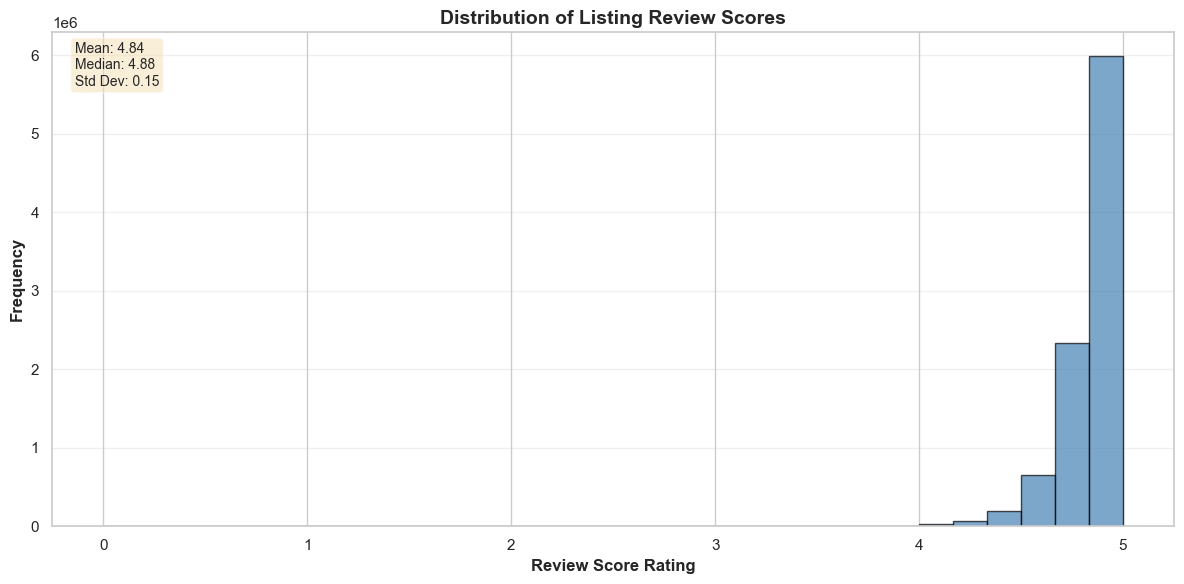


Rating Statistics:
  Mean   : 4.84
  Median : 4.88
  Std Dev: 0.15
  Min    : 0.00
  Max    : 5.00


In [8]:
# Histogram of review_scores_rating distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram
ax.hist(df_full['review_scores_rating'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')

# Add labels and title
ax.set_xlabel('Review Score Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Listing Review Scores', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add statistics text
mean_rating = df_full['review_scores_rating'].mean()
median_rating = df_full['review_scores_rating'].median()
std_rating = df_full['review_scores_rating'].std()

stats_text = f'Mean: {mean_rating:.2f}\nMedian: {median_rating:.2f}\nStd Dev: {std_rating:.2f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nRating Statistics:")
print(f"  Mean   : {mean_rating:.2f}")
print(f"  Median : {median_rating:.2f}")
print(f"  Std Dev: {std_rating:.2f}")
print(f"  Min    : {df_full['review_scores_rating'].min():.2f}")
print(f"  Max    : {df_full['review_scores_rating'].max():.2f}")


In [4]:
# Check actual min values across ALL cities
print("=" * 80)
print("DATA INVESTIGATION: Review Scores Across ALL Cities")
print("=" * 80)

# Overall stats
print(f"\n✓ YES - The histogram is for ALL cities combined (not just Austin)")
print(f"\nTotal reviews in df_full: {len(df_full):,}")
print(f"Cities included: {df_full['city_tag'].unique().tolist()}")

# Check for extremely low scores
print(f"\n--- Minimum Rating Values ---")
print(f"Global minimum: {df_full['review_scores_rating'].min()}")
print(f"Global maximum: {df_full['review_scores_rating'].max()}")

# Count reviews by score range
print(f"\n--- Count by Rating Range ---")
print(f"Score = 1.0: {len(df_full[df_full['review_scores_rating'] == 1.0])}")
print(f"Score = 2.0: {len(df_full[df_full['review_scores_rating'] == 2.0])}")
print(f"Score = 3.0: {len(df_full[df_full['review_scores_rating'] == 3.0])}")
print(f"Score < 4.0: {len(df_full[df_full['review_scores_rating'] < 4.0])}")
print(f"Score < 4.1: {len(df_full[df_full['review_scores_rating'] < 4.1])}")
print(f"Score < 4.2: {len(df_full[df_full['review_scores_rating'] < 4.2])}")
print(f"Score < 4.3: {len(df_full[df_full['review_scores_rating'] < 4.3])}")
print(f"Score < 4.5: {len(df_full[df_full['review_scores_rating'] < 4.5])}")

# Show breakdown by city
print(f"\n--- Minimum Score by City ---")
for city in sorted(df_full['city_tag'].unique()):
    city_data = df_full[df_full['city_tag'] == city]
    min_score = city_data['review_scores_rating'].min()
    count_below_3 = len(city_data[city_data['review_scores_rating'] < 3.0])
    print(f"{city:20s}: min={min_score:.2f} | reviews<3.0={count_below_3:3d}")

# Show sample of very low scores
very_low = df_full[df_full['review_scores_rating'] < 3.0].head(5)
if len(very_low) > 0:
    print(f"\n--- Sample of Reviews with Score < 3.0 ---")
    for idx, (i, row) in enumerate(very_low.iterrows(), 1):
        print(f"{idx}. Score: {row['review_scores_rating']} | City: {row['city_tag']} | Review: {str(row['comments'])[:80]}...")


DATA INVESTIGATION: Review Scores Across ALL Cities

✓ YES - The histogram is for ALL cities combined (not just Austin)

Total reviews in df_full: 9,272,268
Cities included: ['Austin_TX', 'Boston_MA', 'Cambridge_MA', 'Chicago_IL', 'Denver_CO', 'Hawaii_HI', 'LosAngeles_CA', 'Nashville_TN', 'NewOrleans_LA', 'NewYorkCity_NY', 'Oakland_CA', 'Portland_OR', 'SanFrancisco_CA', 'Seattle_WA', 'Washington_DC']

--- Minimum Rating Values ---
Global minimum: 0.0
Global maximum: 5.0

--- Count by Rating Range ---
Score = 1.0: 495
Score = 2.0: 313
Score = 3.0: 1409
Score < 4.0: 11081
Score < 4.1: 24873
Score < 4.2: 38337
Score < 4.3: 69699
Score < 4.5: 283966

--- Minimum Score by City ---
Austin_TX           : min=1.00 | reviews<3.0= 38
Boston_MA           : min=1.00 | reviews<3.0= 14
Cambridge_MA        : min=1.00 | reviews<3.0= 13
Chicago_IL          : min=1.00 | reviews<3.0= 83
Denver_CO           : min=1.00 | reviews<3.0= 12
Hawaii_HI           : min=1.00 | reviews<3.0=120
LosAngeles_CA       :

RATING CATEGORY BREAKDOWN BY CITY (Counts)
rating_label        high    low   medium      All
city_tag                                         
Austin_TX         421359   1047   165618   588024
Boston_MA         101553   1619   112406   215578
Cambridge_MA       43472    150    33159    76781
Chicago_IL        266215   1955   223970   492140
Denver_CO         272458    301    79249   352008
Hawaii_HI         820213   5558   582824  1408595
LosAngeles_CA    1123740   7650   653573  1784963
Nashville_TN      553277   1553   229506   784336
NewOrleans_LA     299901   1699   187350   488950
NewYorkCity_NY    446948  11694   544216  1002858
Oakland_CA         77870    301    50051   128222
Portland_OR       399926    257    99966   500149
SanFrancisco_CA   263990   1590   158585   424165
Seattle_WA        404342   1674   169536   575552
Washington_DC     261691   1289   186967   449947
All              5756955  38337  3476976  9272268

RATING CATEGORY BREAKDOWN BY CITY (Percentages)
rating_l

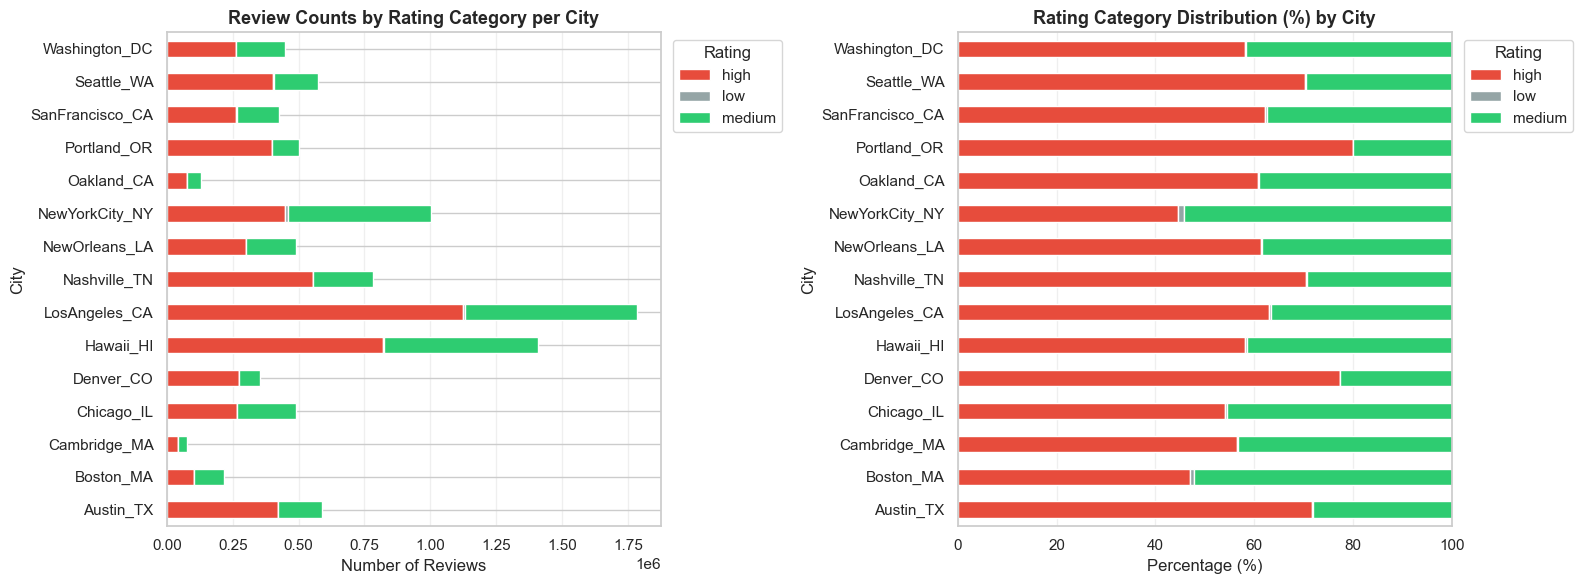

In [4]:
# ── Rating category breakdown by city ─────────────────────────────────────────
# First, create rating labels
df_full["rating_label"] = df_full["review_scores_rating"].apply(
    lambda x: "low" if x < RATING_LOW_MAX else ("medium" if x < RATING_HIGH_MIN else "high")
)

# Create crosstab: cities × rating labels
city_rating_counts = pd.crosstab(df_full["city_tag"], df_full["rating_label"], margins=True)
city_rating_pct = pd.crosstab(df_full["city_tag"], df_full["rating_label"], normalize="index") * 100

# Combine counts and percentages
print("=" * 90)
print("RATING CATEGORY BREAKDOWN BY CITY (Counts)")
print("=" * 90)
print(city_rating_counts.to_string())

print("\n" + "=" * 90)
print("RATING CATEGORY BREAKDOWN BY CITY (Percentages)")
print("=" * 90)
print(city_rating_pct.round(2).to_string())

# Detailed summary table
summary_data = []
for city in df_full["city_tag"].unique():
    city_data = df_full[df_full["city_tag"] == city]
    total = len(city_data)
    low = (city_data["rating_label"] == "low").sum()
    medium = (city_data["rating_label"] == "medium").sum()
    high = (city_data["rating_label"] == "high").sum()
    
    summary_data.append({
        "City": city,
        "Total Reviews": total,
        "Low Count": low,
        "Low %": f"{low/total*100:.1f}%" if total > 0 else "0%",
        "Medium Count": medium,
        "Medium %": f"{medium/total*100:.1f}%" if total > 0 else "0%",
        "High Count": high,
        "High %": f"{high/total*100:.1f}%" if total > 0 else "0%",
    })

summary_df = pd.DataFrame(summary_data).sort_values("Total Reviews", ascending=False)
print("\n" + "=" * 90)
print("DETAILED SUMMARY: Rating Distribution by City")
print("=" * 90)
print(summary_df.to_string(index=False))

# Visualization: Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts (stacked)
city_rating_counts_plot = city_rating_counts.drop("All", axis=0).drop("All", axis=1)
city_rating_counts_plot.plot(kind="barh", stacked=True, ax=axes[0],
                              color=["#e74c3c", "#95a5a6", "#2ecc71"],
                              edgecolor="white")
axes[0].set_title("Review Counts by Rating Category per City", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("City")
axes[0].legend(title="Rating", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].grid(axis="x", alpha=0.3)

# Percentages (100% stacked)
city_rating_pct_plot = city_rating_pct.drop("All", axis=0) if "All" in city_rating_pct.index else city_rating_pct
city_rating_pct_plot.plot(kind="barh", stacked=True, ax=axes[1],
                          color=["#e74c3c", "#95a5a6", "#2ecc71"],
                          edgecolor="white")
axes[1].set_title("Rating Category Distribution (%) by City", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Percentage (%)")
axes[1].set_ylabel("City")
axes[1].set_xlim(0, 100)
axes[1].legend(title="Rating", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 2. Sampling

**Sampling pipeline (in order):**

1. **Short review filter** (< 10 words) — removes near-empty reviews ("Great!", "Nice.")
   that add noise to TF-IDF and LDA without contributing signal. Threshold is 10 rather than 20
   to preserve short negative reviews ("Dirty. Noisy. Broken AC.") which are rare and valuable
   for predicting the minority "low" class. Applied first so the city sampling pool is already clean.
2. **Two-stage sample per city**
   - *Stage A* — cap each listing at `REVIEWS_PER_LISTING` reviews. Prevents a handful of
     popular listings from dominating the sample and teaching the model listing-specific language.
   - *Stage B* — draw exactly `SAMPLE_N_PER_CITY` (4,000) reviews per city. If a city has
     fewer than 4,000 reviews after the listing cap, all available reviews are kept and a warning
     is printed. This fixed draw guarantees equal city representation for all downstream
     city-level comparisons.
3. **English filter** — applied *after* sampling using langdetect. Removes any non-English reviews
   that slipped through. Applied post-sampling so city targets are drawn from the broadest possible
   pool before language screening reduces the final count slightly.
4. **Sample EDA** — per-city review counts and rating label balance check to confirm equal
   city representation and assess class imbalance before modelling.
5. **Validation** — KS-tests compare rating and review-length distributions between the pre-English
   pool and the final sample.


In [10]:
import numpy as np

# ── Step: Remove short reviews before sampling ───────────────────────────────────────────────

# Word count
df_full["word_count"] = df_full["comments"].astype(str).str.split().str.len()

n_before = len(df_full)

# Rating labels (you can reuse later)
def label_rating(score):
    if pd.isna(score):      
        return np.nan
    elif score < RATING_LOW_MAX:    
        return "low"
    elif score < RATING_HIGH_MIN: 
        return "medium"
    else:                         
        return "high"

df_full["rating_label"] = df_full["review_scores_rating"].apply(label_rating)

# Distribution BEFORE
before_dist = df_full["rating_label"].value_counts(normalize=True).round(3)

# Apply filter
df_filtered = df_full[df_full["word_count"] >= MIN_REVIEW_WORDS].copy()

# Distribution AFTER
after_dist = df_filtered["rating_label"].value_counts(normalize=True).round(3)

# Reporting
print(f"Short review filter (< {MIN_REVIEW_WORDS} words):")
print(f"  Removed: {n_before - len(df_filtered):,}")
print(f"  Kept   : {len(df_filtered):,}")

# Compare distributions
check = pd.DataFrame({"before": before_dist, "after": after_dist})
check["shift"] = (check["after"] - check["before"]).round(3)

print("\nRating class distribution shift:")
print(check.to_string())

print("\nInterpretation:")
print("- Negative shift = that class was disproportionately removed")


Short review filter (< 10 words):
  Removed: 1,468,547
  Kept   : 7,803,721

Rating class distribution shift:
              before  after  shift
rating_label                      
high           0.621  0.637  0.016
medium         0.375  0.359 -0.016
low            0.004  0.004  0.000

Interpretation:
- Negative shift = that class was disproportionately removed


In [12]:
# ── Step 2: Three-stage sample — listing cap then fixed draw per city ──────────
if "listing_id" not in df_filtered.columns:
    raise ValueError("Column 'listing_id' not found. Check the parquet file.")

if "rating_label" not in df_filtered.columns:
    raise ValueError("Column 'rating_label' not found. Check the parquet file.")

RATING_CATEGORIES = ["low", "medium", "high"]

sampled_parts = []

for city, city_grp in df_filtered.groupby("city_tag"):

    # Stage A: cap reviews per listing to avoid popular listings dominating
    capped = (
        city_grp
        .groupby("listing_id", group_keys=False)
        .apply(lambda g: g.sample(n=min(REVIEWS_PER_LISTING, len(g)),
                                  random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

    # Stage B: draw exactly SAMPLE_N_PER_CITY reviews from the capped pool
    if len(capped) < SAMPLE_N_PER_CITY:
        print(f"  ⚠  {city}: only {len(capped):,} reviews after listing cap — keeping all")
        sampled_parts.append(capped)
        continue

    # Stage C: stratified draw by rating_label to balance sentiment categories
    # Target: equal share per rating category; fall back to whatever is available
    target_per_category = SAMPLE_N_PER_CITY // len(RATING_CATEGORIES)
    remainder = SAMPLE_N_PER_CITY % len(RATING_CATEGORIES)   # distribute leftover to first N bins

    rating_parts = []
    shortfall = 0  # reviews we couldn't fill from an under-represented category

    category_pools = {cat: capped[capped["rating_label"] == cat] for cat in RATING_CATEGORIES}

    # First pass: collect as many as possible per category, track shortfall
    allotments = {}
    for i, cat in enumerate(RATING_CATEGORIES):
        allotment = target_per_category + (1 if i < remainder else 0)
        pool = category_pools[cat]
        if len(pool) < allotment:
            print(f"  ⚠  {city} / {cat}: only {len(pool):,} reviews available "
                  f"(wanted {allotment:,}) — shortfall of {allotment - len(pool):,}")
            shortfall += allotment - len(pool)
            allotments[cat] = len(pool)   # take everything available
        else:
            allotments[cat] = allotment

    # Second pass: redistribute shortfall to categories that have surplus
    if shortfall > 0:
        for cat in RATING_CATEGORIES:
            if shortfall == 0:
                break
            pool = category_pools[cat]
            surplus = len(pool) - allotments[cat]
            if surplus > 0:
                boost = min(surplus, shortfall)
                allotments[cat] += boost
                shortfall -= boost

    # Final draw per category
    for cat in RATING_CATEGORIES:
        pool = category_pools[cat]
        n = allotments[cat]
        if n > 0:
            rating_parts.append(pool.sample(n=n, random_state=RANDOM_STATE))

    city_sample = pd.concat(rating_parts).reset_index(drop=True)
    sampled_parts.append(city_sample)

df = pd.concat(sampled_parts).reset_index(drop=True)

print(f"\nSample size     : {len(df):,} reviews  |  {df['city_tag'].nunique()} cities")
print(f"Target per city : {SAMPLE_N_PER_CITY:,}")
print(f"Target per rating category : {SAMPLE_N_PER_CITY // len(RATING_CATEGORIES):,}")
print("\nPer-city counts:")
print(df["city_tag"].value_counts().sort_values(ascending=False).to_string())
print("\nRating label distribution in sample:")
print(df["rating_label"].value_counts().to_string())
print("\nRating distribution per city:")
print(df.groupby(["city_tag", "rating_label"]).size().unstack(fill_value=0).to_string())


  ⚠  Austin_TX / low: only 626 reviews available (wanted 1,334) — shortfall of 708
  ⚠  Boston_MA / low: only 436 reviews available (wanted 1,334) — shortfall of 898
  ⚠  Cambridge_MA / low: only 72 reviews available (wanted 1,334) — shortfall of 1,262
  ⚠  Chicago_IL / low: only 903 reviews available (wanted 1,334) — shortfall of 431
  ⚠  Denver_CO / low: only 228 reviews available (wanted 1,334) — shortfall of 1,106
  ⚠  Nashville_TN / low: only 543 reviews available (wanted 1,334) — shortfall of 791
  ⚠  NewOrleans_LA / low: only 746 reviews available (wanted 1,334) — shortfall of 588
  ⚠  Oakland_CA / low: only 150 reviews available (wanted 1,334) — shortfall of 1,184
  ⚠  Portland_OR / low: only 151 reviews available (wanted 1,334) — shortfall of 1,183
  ⚠  SanFrancisco_CA / low: only 634 reviews available (wanted 1,334) — shortfall of 700
  ⚠  Seattle_WA / low: only 651 reviews available (wanted 1,334) — shortfall of 683
  ⚠  Washington_DC / low: only 587 reviews available (wante

In [ ]:
# ── DIAGNOSTIC: Trace Austin's "low" reviews through each filter ─────────────────

print("=" * 90)
print("DIAGNOSTIC: Austin's LOW-RATED Reviews After Each Filtering Step")
print("=" * 90)

# Step 0: Raw full dataset
austin_full = df_full[df_full["city_tag"] == "Austin_TX"]
austin_low_full = austin_full[austin_full["rating_label"] == "low"]
print(f"\n1. RAW dataset (df_full):")
print(f"   Austin total reviews: {len(austin_full):,}")
print(f"   Austin LOW reviews (<{RATING_LOW_MAX}): {len(austin_low_full):,}")
print(f"   Percentage: {len(austin_low_full)/len(austin_full)*100:.1f}%")

# Show word count distribution for Austin's low-rated reviews
print(f"\n   Word count stats for Austin LOW reviews:")
print(f"   Median: {austin_low_full['word_count'].median():.0f} words")
print(f"   Mean: {austin_low_full['word_count'].mean():.1f} words")
print(f"   < 10 words: {(austin_low_full['word_count'] < MIN_REVIEW_WORDS).sum():,} ({(austin_low_full['word_count'] < MIN_REVIEW_WORDS).sum()/len(austin_low_full)*100:.1f}%)")

# Step 1: After short review filter
austin_filtered = df_filtered[df_filtered["city_tag"] == "Austin_TX"]
austin_low_filtered = austin_filtered[austin_filtered["rating_label"] == "low"]
print(f"\n2. AFTER short review filter (MIN_REVIEW_WORDS >= {MIN_REVIEW_WORDS}):")
print(f"   Austin total reviews: {len(austin_filtered):,}")
print(f"   Austin LOW reviews: {len(austin_low_filtered):,}")
print(f"   Percentage: {len(austin_low_filtered)/len(austin_filtered)*100:.1f}%")
print(f"   ⚠️  LOW reviews removed: {len(austin_low_full) - len(austin_low_filtered):,} ({(len(austin_low_full) - len(austin_low_filtered))/len(austin_low_full)*100:.1f}%)")

# Step 2: After listing cap
austin_after_cap = pd.concat([part.reset_index(drop=True) for part in [
    df_filtered[df_filtered["city_tag"] == "Austin_TX"]
    .groupby("listing_id", group_keys=False)
    .apply(lambda g: g.sample(n=min(REVIEWS_PER_LISTING, len(g)), random_state=RANDOM_STATE))
]])
austin_low_cap = austin_after_cap[austin_after_cap["rating_label"] == "low"]
print(f"\n3. AFTER listing cap (max {REVIEWS_PER_LISTING} reviews/listing):")
print(f"   Austin total reviews: {len(austin_after_cap):,}")
print(f"   Austin LOW reviews: {len(austin_low_cap):,}")
print(f"   Percentage: {len(austin_low_cap)/len(austin_after_cap)*100:.1f}%")

# Step 3: Final sampled dataset
austin_sampled = df[df["city_tag"] == "Austin_TX"]
austin_low_sampled = austin_sampled[austin_sampled["rating_label"] == "low"]
print(f"\n4. FINAL sample (df) — after stratified sampling + English filter:")
print(f"   Austin total reviews: {len(austin_sampled):,}")
print(f"   Austin LOW reviews: {len(austin_low_sampled):,}")
print(f"   Percentage: {len(austin_low_sampled)/len(austin_sampled)*100:.1f}%")
print(f"   ⚠️  LOW reviews lost: {len(austin_low_filtered) - len(austin_low_sampled):,} ({(len(austin_low_filtered) - len(austin_low_sampled))/len(austin_low_filtered)*100:.1f}%)")

# Summary breakdown
print("\n" + "=" * 90)
print("SUMMARY: Why Austin lost LOW reviews")
print("=" * 90)
loss_to_short_filter = len(austin_low_full) - len(austin_low_filtered)
loss_to_stratified = len(austin_low_filtered) - len(austin_low_sampled)
print(f"Raw dataset → After short-word filter: -{loss_to_short_filter:,} LOW reviews ({loss_to_short_filter/len(austin_low_full)*100:.1f}%)")
print(f"  → This happened because LOW reviews are often SHORT: e.g., 'Dirty!', 'Broken AC!'")
print(f"  → Positive reviews tend to be longer: 'The place was amazing, great location...'")
print(f"\nAfter short-word filter → Final sample: -{loss_to_stratified:,} LOW reviews ({loss_to_stratified/len(austin_low_filtered)*100:.1f}%)")
print(f"  → This happened because stratified sampling has limits:")
print(f"  → Target per category: ~{SAMPLE_N_PER_CITY // 3:,} per city")
print(f"  → If LOW pool is depleted by word filter, sampling reallocates to other categories")
print(f"\nTOTAL loss: {len(austin_low_full) - len(austin_low_sampled):,} LOW reviews")
print(f"  → {len(austin_low_full):,} (raw) → {len(austin_low_sampled):,} (sampled) = {(len(austin_low_full) - len(austin_low_sampled))/len(austin_low_full)*100:.1f}% reduction")


DIAGNOSTIC: Austin's LOW-RATED Reviews After Each Filtering Step

1. RAW dataset (df_full):
   Austin total reviews: 588,024
   Austin LOW reviews (<4.2): 1,047
   Percentage: 0.2%

   Word count stats for Austin LOW reviews:


KeyError: 'word_count'

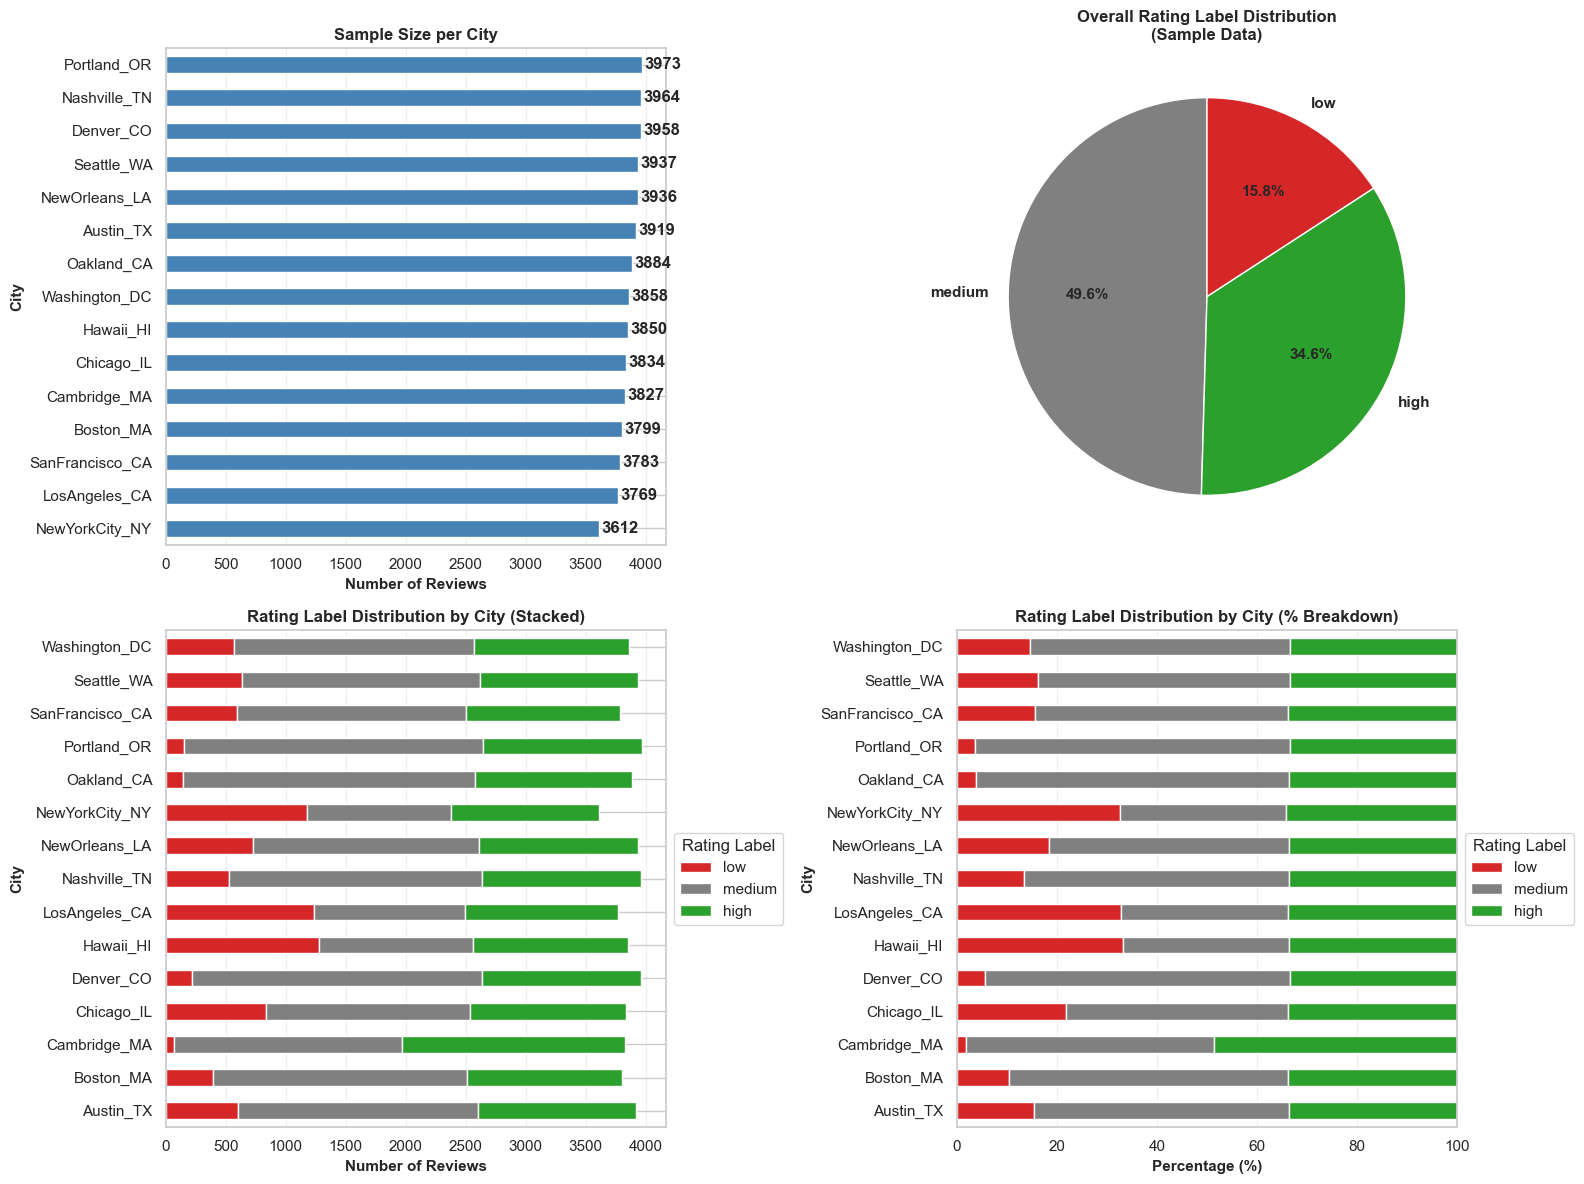


SAMPLE DATA COMPOSITION SUMMARY

Total reviews sampled: 57,903
Total cities: 15

Rating Label Breakdown (Overall):
rating_label
medium    28692
high      20050
low        9161

Rating Label Percentages:
rating_label
medium    49.55
high      34.63
low       15.82


In [35]:
# Visualizations: Sample Composition by City and Rating Label
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Reviews per city (bar chart)
ax1 = axes[0, 0]
city_counts = df["city_tag"].value_counts().sort_values(ascending=True)
city_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Reviews', fontsize=11, fontweight='bold')
ax1.set_ylabel('City', fontsize=11, fontweight='bold')
ax1.set_title('Sample Size per City', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(city_counts.values):
    ax1.text(v + 20, i, str(v), va='center', fontweight='bold')

# 2. Overall rating label distribution (pie chart)
ax2 = axes[0, 1]
rating_dist = df["rating_label"].value_counts()
colors = {'low': '#d62728', 'medium': '#808080', 'high': '#2ca02c'}
pie_colors = [colors[label] for label in rating_dist.index]
wedges, texts, autotexts = ax2.pie(rating_dist.values, labels=rating_dist.index, autopct='%1.1f%%',
                                     colors=pie_colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Overall Rating Label Distribution\n(Sample Data)', fontsize=12, fontweight='bold')

# 3. Stacked bar chart: Rating distribution per city
ax3 = axes[1, 0]
city_rating_crosstab = pd.crosstab(df['city_tag'], df['rating_label'])
city_rating_crosstab = city_rating_crosstab.reindex(columns=['low', 'medium', 'high'], fill_value=0)
city_rating_crosstab.plot(kind='barh', stacked=True, ax=ax3, color=[colors['low'], colors['medium'], colors['high']])
ax3.set_xlabel('Number of Reviews', fontsize=11, fontweight='bold')
ax3.set_ylabel('City', fontsize=11, fontweight='bold')
ax3.set_title('Rating Label Distribution by City (Stacked)', fontsize=12, fontweight='bold')
ax3.legend(title='Rating Label', loc='center left', bbox_to_anchor=(1, 0.5))
ax3.grid(axis='x', alpha=0.3)

# 4. Percentage distribution per city (100% stacked)
ax4 = axes[1, 1]
city_rating_pct = city_rating_crosstab.div(city_rating_crosstab.sum(axis=1), axis=0) * 100
city_rating_pct.plot(kind='barh', stacked=True, ax=ax4, color=[colors['low'], colors['medium'], colors['high']])
ax4.set_xlabel('Percentage (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('City', fontsize=11, fontweight='bold')
ax4.set_title('Rating Label Distribution by City (% Breakdown)', fontsize=12, fontweight='bold')
ax4.legend(title='Rating Label', loc='center left', bbox_to_anchor=(1, 0.5))
ax4.set_xlim([0, 100])
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SAMPLE DATA COMPOSITION SUMMARY")
print("="*80)
print(f"\nTotal reviews sampled: {len(df):,}")
print(f"Total cities: {df['city_tag'].nunique()}")
print(f"\nRating Label Breakdown (Overall):")
print(df["rating_label"].value_counts().to_string())
print(f"\nRating Label Percentages:")
print((df["rating_label"].value_counts() / len(df) * 100).round(2).to_string())


In [15]:
print("\nRating label distribution in sample:")
print(df["rating_label"].value_counts().to_string())


Rating label distribution in sample:
rating_label
medium    29683
high      20588
low        9729


To mitigate the right-skewed data, we will apply class_weight='balanced' in all three LR models to directly compensates by upweighting the minority classes during training.

In [16]:
# Quick confirmation — sample counts before English filter
print(f"Reviews before English filter: {len(df):,}  |  {df['city_tag'].nunique()} cities")


Reviews before English filter: 60,000  |  15 cities


In [17]:
# ── Step 4: English filter (post-sampling) ───────────────────────────────────
def is_english_combined(text, min_tokens=3, ascii_threshold=0.5, prob_threshold=0.8):
    text = str(text).strip()
    tokens = text.split()

    if len(tokens) < min_tokens:
        return False

    ascii_ratio = sum(t.isascii() for t in tokens) / len(tokens)
    if ascii_ratio < ascii_threshold:
        return False

    try:
        langs = detect_langs(text)
        return any(l.lang == 'en' and l.prob >= prob_threshold for l in langs)
    except:
        return False


df_en = df[df["comments"].apply(is_english_combined)].copy()

print(f"Before English filter : {len(df):,} reviews")
print(f"After English filter  : {len(df_en):,} reviews")
print(f"Removed (non-English) : {len(df) - len(df_en):,} reviews  ({(1 - len(df_en)/len(df))*100:.1f}%)")

# Use df_en as the working dataframe going forward
df = df_en.copy()
del df_en
print(f"\nWorking dataframe set to df_en  →  {len(df):,} reviews")

Before English filter : 60,000 reviews
After English filter  : 57,903 reviews
Removed (non-English) : 2,097 reviews  (3.5%)

Working dataframe set to df_en  →  57,903 reviews


### 2.5 Sample EDA — City Counts & Rating Label Balance

REVIEWS PER CITY (after sampling + English filter)
           city  n_reviews  pct_of_total
    Portland_OR       3973           6.9
   Nashville_TN       3964           6.8
      Denver_CO       3958           6.8
     Seattle_WA       3937           6.8
  NewOrleans_LA       3936           6.8
      Austin_TX       3919           6.8
     Oakland_CA       3884           6.7
  Washington_DC       3858           6.7
      Hawaii_HI       3850           6.6
     Chicago_IL       3834           6.6
   Cambridge_MA       3827           6.6
      Boston_MA       3799           6.6
SanFrancisco_CA       3783           6.5
  LosAngeles_CA       3769           6.5
 NewYorkCity_NY       3612           6.2

Total reviews : 57,903
Cities        : 15
Target/city   : 4,000  (deviations caused by English filter post-sampling)


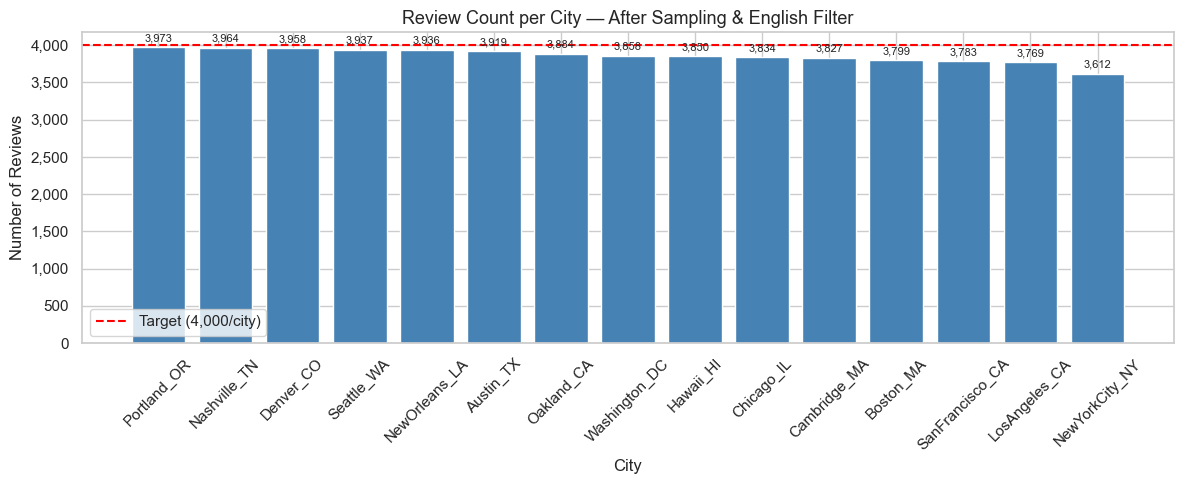


RATING LABEL BALANCE (full sample)
              count   pct
rating_label             
medium        28692  49.6
high          20050  34.6
low            9161  15.8

→ Imbalance interpretation:
   low     : 15.8%  ⚠  minority — use class_weight='balanced' in models
   medium  : 49.6%  ✓  well-represented
   high    : 34.6%  ✓  well-represented

RATING LABEL BALANCE PER CITY
rating_label      low  medium  high
city_tag                           
Austin_TX        15.4    51.0  33.6
Boston_MA        10.3    55.8  33.9
Cambridge_MA      1.8    49.7  48.5
Chicago_IL       21.9    44.3  33.9
Denver_CO         5.6    61.0  33.4
Hawaii_HI        33.2    33.2  33.6
LosAngeles_CA    32.8    33.4  33.9
Nashville_TN     13.3    53.1  33.5
NewOrleans_LA    18.4    48.0  33.6
NewYorkCity_NY   32.6    33.1  34.2
Oakland_CA        3.8    62.6  33.6
Portland_OR       3.7    62.8  33.4
SanFrancisco_CA  15.7    50.5  33.8
Seattle_WA       16.2    50.4  33.4
Washington_DC    14.6    51.9  33.4


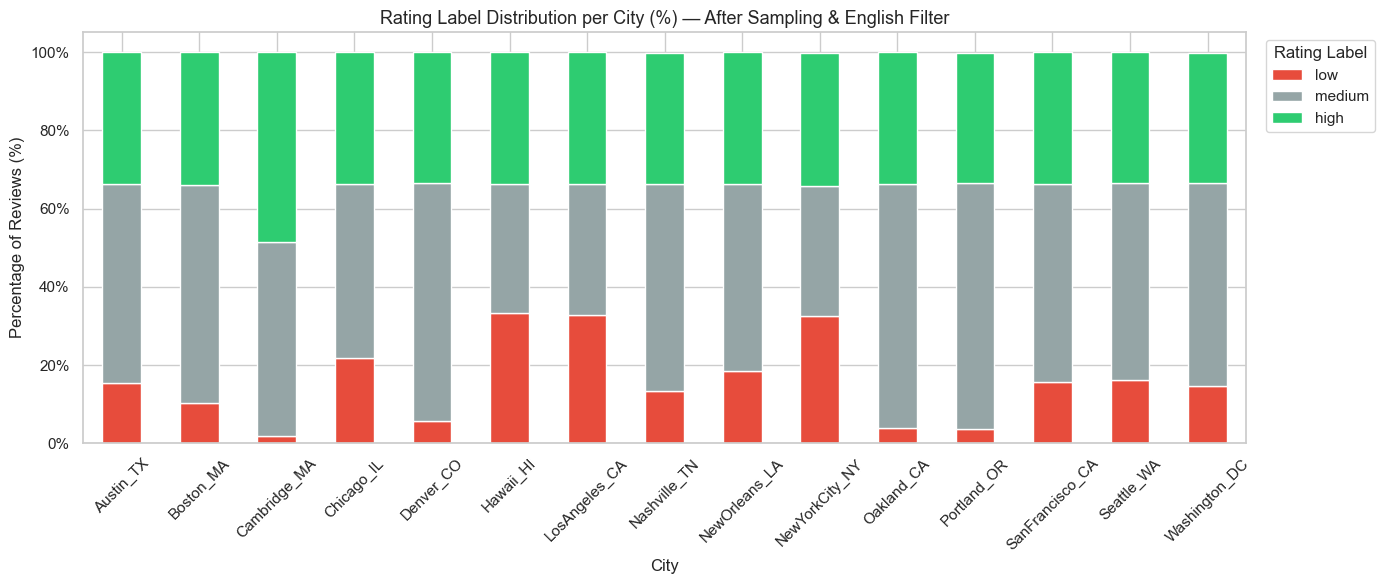


→ Summary: Airbnb ratings are right-skewed (most reviews are 'high').
   Rating-stratified sampling preserves natural class ratios per city.
   Use class_weight='balanced' in all classifiers to handle imbalance.


In [18]:
# ── Sample EDA: Per-city review counts ───────────────────────────────────────
print("=" * 55)
print("REVIEWS PER CITY (after sampling + English filter)")
print("=" * 55)
city_counts = df["city_tag"].value_counts().sort_values(ascending=False)
city_counts_df = city_counts.reset_index()
city_counts_df.columns = ["city", "n_reviews"]
city_counts_df["pct_of_total"] = (city_counts_df["n_reviews"] / len(df) * 100).round(1)
print(city_counts_df.to_string(index=False))
print(f"\nTotal reviews : {len(df):,}")
print(f"Cities        : {df['city_tag'].nunique()}")
print(f"Target/city   : {SAMPLE_N_PER_CITY:,}  (deviations caused by English filter post-sampling)")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_counts.index, city_counts.values, color="steelblue", edgecolor="white")
ax.axhline(SAMPLE_N_PER_CITY, color="red", linestyle="--", linewidth=1.5, label=f"Target ({SAMPLE_N_PER_CITY:,}/city)")
ax.bar_label(bars, labels=[f"{v:,}" for v in city_counts.values], padding=3, fontsize=8)
ax.set_title("Review Count per City — After Sampling & English Filter", fontsize=13)
ax.set_xlabel("City")
ax.set_ylabel("Number of Reviews")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()

# ── Rating label balance ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RATING LABEL BALANCE (full sample)")
print("=" * 55)
label_vc = df["rating_label"].value_counts()
label_df = pd.DataFrame({
    "count": label_vc,
    "pct"  : (label_vc / label_vc.sum() * 100).round(1)
})
print(label_df.to_string())

print("\n→ Imbalance interpretation:")
for lbl in ["low", "medium", "high"]:
    if lbl in label_df.index:
        pct = label_df.loc[lbl, "pct"]
        flag = "⚠  minority — use class_weight='balanced' in models" if pct < 20 else "✓  well-represented"
        print(f"   {lbl:8s}: {pct:.1f}%  {flag}")

# ── Rating balance per city ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RATING LABEL BALANCE PER CITY")
print("=" * 55)
city_label = (df.groupby(["city_tag", "rating_label"])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=["low", "medium", "high"], fill_value=0))
city_label_pct = city_label.div(city_label.sum(axis=1), axis=0).round(3) * 100
print(city_label_pct.to_string())

# Visual: stacked bar
fig, ax = plt.subplots(figsize=(14, 6))
city_label_pct[["low", "medium", "high"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#e74c3c", "#95a5a6", "#2ecc71"], edgecolor="white"
)
ax.set_title("Rating Label Distribution per City (%) — After Sampling & English Filter", fontsize=13)
ax.set_xlabel("City")
ax.set_ylabel("Percentage of Reviews (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Rating Label", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

print("\n→ Summary: Airbnb ratings are right-skewed (most reviews are 'high').")
print("   Rating-stratified sampling preserves natural class ratios per city.")
print("   Use class_weight='balanced' in all classifiers to handle imbalance.")


KS-test Rating score  : stat=0.2935, p=0.0000  ⚠ shifted (expected — rating stratification controls this)
KS-test Review length : stat=0.0373, p=0.0000  ⚠ shifted (expected — rating stratification controls this)


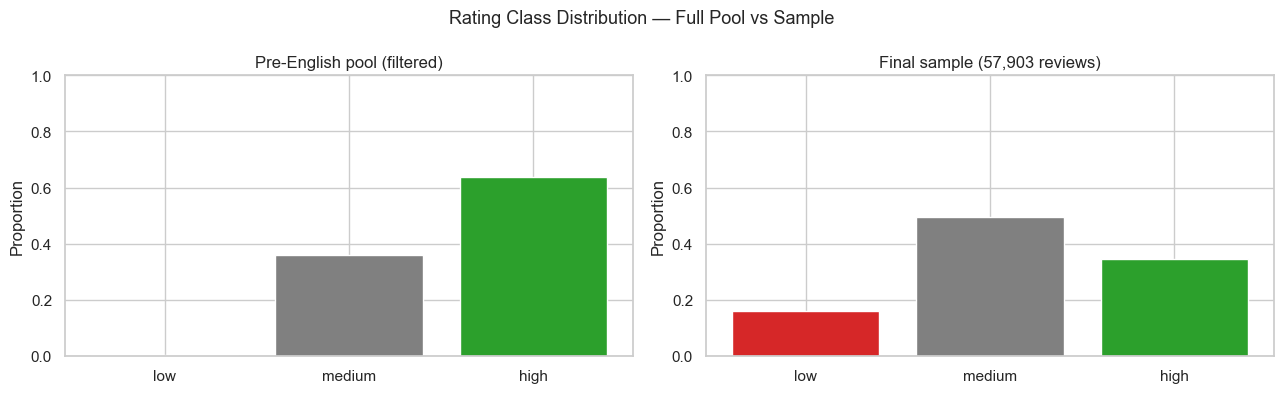

In [85]:
# ── Step 5: Validate sample distributions (pre-English pool vs final sample) ──
from scipy.stats import ks_2samp

for col, label in [("review_scores_rating", "Rating score  "),
                   ("word_count",           "Review length ")]:
    if col in df_filtered.columns and col in df.columns:
        stat, p = ks_2samp(df_filtered[col].dropna(), df[col].dropna())
        verdict = "✓ similar" if p > 0.05 else "⚠ shifted (expected — rating stratification controls this)"
        print(f"KS-test {label}: stat={stat:.4f}, p={p:.4f}  {verdict}")

# Visual check: rating distribution full pool vs sample
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Define consistent color mapping
colors = {'low': '#d62728', 'medium': '#808080', 'high': '#2ca02c'}
label_order = ['low', 'medium', 'high']

for ax, data, title in zip(axes,
                            [df_filtered, df],
                            ["Pre-English pool (filtered)", f"Final sample ({len(df):,} reviews)"]):
    vc = data["rating_label"].value_counts()
    
    # Ensure all labels are present (even with 0 count) for consistent coloring
    vc = vc.reindex(label_order, fill_value=0)
    
    # Get corresponding colors in the correct order
    bar_colors = [colors[label] for label in vc.index]
    
    ax.bar(vc.index, vc.values / vc.sum(),
           color=bar_colors, edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)
plt.suptitle("Rating Class Distribution — Full Pool vs Sample", fontsize=13)
plt.tight_layout()
plt.show()


Pre-English pool is he result of filtering out reviews with fewer than MIN_REVIEW_WORDS words. Low

---
## 3. Text Preprocessing

All reviews in `df` are already English (filtered in Section 2) — no language detection needed here.

Two cleaning pipelines:
- **VADER** — minimal: strip HTML, normalise whitespace. Preserves negation, intensifiers, capitalisation.
- **TF-IDF / LDA** — heavy: lowercase → HTML strip → remove punctuation/digits → tokenise → remove stopwords → drop docs with < 5 tokens.


In [28]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

# ── FIX 1: Negation-safe stopwords ───────────────────────────────────────────
# NLTK's default stopword list includes negations (not, never, didn't, can't …).
# Removing them from reviews strips the signal that distinguishes "clean" from
# "not clean", which directly biases TF-IDF and LDA against negative reviews.
# Solution: carve NEGATIONS out of the NLTK list before building any stop-word set.
NEGATIONS = {
    "no", "not", "nor", "never", "nobody", "nothing", "nowhere", "neither",
    "without", "hardly", "barely", "scarcely",
    "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "won't", "wouldn't", "can't", "cannot", "couldn't", "shouldn't",
    "hasn't", "haven't", "hadn't",
}

# Base = NLTK English minus negations — all downstream stop-word sets derive from this
STOP_WORDS_BASE = set(stopwords.words("english")) - NEGATIONS

# Assert: no negation should be in any downstream stop-word set
def _assert_no_negations(sw_set, name):
    leaked = NEGATIONS & sw_set
    assert not leaked, f"NEGATION LEAK in {name}: {leaked}"

# ── Domain stopwords: TF-IDF ─────────────────────────────────────────────────
DOMAIN_STOP_TFIDF = {
    "airbnb", "stay", "stayed", "place", "apartment", "house", "home",
    "great", "good", "nice", "really", "would", "recommend", "definitely",
    "everything", "just", "also", "listing", "guest",
}

# ── Domain stopwords: LDA (superset of TF-IDF) ───────────────────────────────
DOMAIN_STOP_LDA = DOMAIN_STOP_TFIDF | {
    "perfect", "wonderful", "amazing", "fantastic", "excellent",
    "night", "nights", "week", "days", "one", "two",
    "get", "got", "came", "come", "back",
    "very", "quite", "pretty", "little", "bit", "still", "even",
}

# ── City names (applied to both) ─────────────────────────────────────────────
city_stop = set()
for cn in df["city_tag"].str.replace("_", " ").str.lower().unique():
    city_stop.update(cn.split())

STOP_WORDS_TFIDF = STOP_WORDS_BASE | DOMAIN_STOP_TFIDF | city_stop
STOP_WORDS_LDA   = STOP_WORDS_BASE | DOMAIN_STOP_LDA   | city_stop

# Guard: ensure no negations leaked into either stop-word set
_assert_no_negations(STOP_WORDS_TFIDF, "STOP_WORDS_TFIDF")
_assert_no_negations(STOP_WORDS_LDA,   "STOP_WORDS_LDA")

print(f"Stopword counts — TF-IDF: {len(STOP_WORDS_TFIDF)} | LDA: {len(STOP_WORDS_LDA)}")
print(f"Negations preserved (not removed): {sorted(NEGATIONS)}")

# ── Regex patterns ────────────────────────────────────────────────────────────
HTML_RE       = re.compile(r"<[^>]+>|&\w+;|\r|\n")
PUNC_RE       = re.compile(r"[^a-z\s]")
SPACE_RE      = re.compile(r"\s+")
VADER_HTML_RE = re.compile(r"<[^>]+>|&\w+;")

# ── FIX 2: encode_negations() fuses "not clean" → "not_clean" before LDA ─────
# This ensures compound negation tokens survive into the LDA vocabulary instead
# of being split and having "not" removed as a stop-word.
def encode_negations(text: str) -> str:
    """Fuse negation + next token: 'not clean' → 'not_clean', 'didn't work' → 'didn_t_work'."""
    tokens = text.split()
    out    = []
    i      = 0
    while i < len(tokens):
        t = tokens[i].lower()
        if t in NEGATIONS and i + 1 < len(tokens):
            # Strip punctuation from the negation token (e.g. "didn't" → "didnt")
            neg_clean  = re.sub(r"[^a-z]", "", t)
            next_clean = re.sub(r"[^a-z]", "", tokens[i + 1].lower())
            if next_clean:
                out.append(f"{neg_clean}_{next_clean}")
                i += 2
                continue
        out.append(tokens[i])
        i += 1
    return " ".join(out)

# ── Cleaning functions ────────────────────────────────────────────────────────
def clean_for_vader(text: str) -> str:
    """Minimal cleaning — preserves negation, capitalisation, punctuation."""    
    text = str(text)
    text = VADER_HTML_RE.sub(" ", text)
    text = re.sub(r"[\r\n]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def _base_clean(text: str) -> list:
    """Shared normalisation: lowercase → strip HTML → remove punctuation/digits → tokenise."""    
    text = str(text).lower()
    text = HTML_RE.sub(" ", text)
    text = PUNC_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return word_tokenize(text)

def preprocess_tfidf(text: str) -> str:
    """Heavy clean for TF-IDF: removes negation-safe NLTK + domain Airbnb stopwords."""    
    tokens = _base_clean(text)
    tokens = [t for t in tokens if t not in STOP_WORDS_TFIDF and len(t) > 2]
    return " ".join(tokens)

def preprocess_lda(text: str) -> str:
    """Heavy clean for LDA: encode negations first, then apply superset stopwords."""    # Step 1: fuse negations BEFORE lowercasing strips the apostrophes
    text   = encode_negations(text)
    # Step 2: standard heavy cleaning
    tokens = _base_clean(text)
    tokens = [t for t in tokens if t not in STOP_WORDS_LDA and len(t) > 2]
    return " ".join(tokens)

# ── Apply both pipelines ──────────────────────────────────────────────────────
print("Preprocessing — TF-IDF pipeline...")
df["clean_text_tfidf"] = df["comments"].progress_apply(preprocess_tfidf)

print("Preprocessing — LDA pipeline...")
df["clean_text_lda"] = df["comments"].progress_apply(preprocess_lda)

print(f"Preprocessing complete: {len(df):,} reviews")

# Quick sanity check: confirm negation tokens appear in LDA-cleaned text
neg_examples = df["clean_text_lda"].str.contains(r"\bnot_|\bdidnt_|\bdoesnt_", regex=True)
print(f"Reviews with fused negation tokens in LDA text: {neg_examples.sum():,}")

df[["comments", "clean_text_tfidf", "clean_text_lda"]].head(3)


Stopword counts — TF-IDF: 224 | LDA: 246
Negations preserved (not removed): ["aren't", 'barely', "can't", 'cannot', "couldn't", "didn't", "doesn't", "don't", "hadn't", 'hardly', "hasn't", "haven't", "isn't", 'neither', 'never', 'no', 'nobody', 'nor', 'not', 'nothing', 'nowhere', 'scarcely', "shouldn't", "wasn't", "weren't", 'without', "won't", "wouldn't"]
Preprocessing — TF-IDF pipeline...


  0%|          | 0/57903 [00:00<?, ?it/s]

Preprocessing — LDA pipeline...


  0%|          | 0/57903 [00:00<?, ?it/s]

Preprocessing complete: 57,903 reviews
Reviews with fused negation tokens in LDA text: 0


,comments,clean_text_tfidf,clean_text_lda
0,"I was sent to Austin for a short assignment, found this place for an extended stay. Great price for the area it is l...",sent short assignment found extended price area located quick access highway downtown area,sent short assignment found extended price area located quick access highway downtown area
1,"I greatly enjoyed my extended stay at Dina’s! She makes you feel right at home, checks in to make sure the stay is g...",greatly enjoyed extended dina makes feel right checks make sure going smoothly responsive entire time anyone needs a...,greatly enjoyed extended dina makes feel right checks make sure going smoothly responsive entire time anyone needs a...
2,"I recently had a trip with my girlfriend, and while the stay was decent, it had a motel-like vibe. Unfortunately, we...",recently trip girlfriend decent motel like vibe unfortunately encountered cockroach issues one found trash woke anot...,recently trip girlfriend decent motel like vibe unfortunately encountered cockroach issues found trash woke another ...


---
## 4. Sentiment Analysis

### 4.0 VADER — Background & Justification

**What VADER is**  
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon- and rule-based sentiment
analyser designed for social media text. It combines a ~7,500-token sentiment lexicon with five
grammatical heuristics — punctuation ("!!!"), capitalisation ("GREAT"), degree modifiers ("very"),
conjunctions ("but"), and negation ("not") — to produce `pos`, `neg`, `neu`, and a normalised
`compound` score in [−1, +1].

**Why it fits Airbnb reviews**  
Airbnb reviews are short (median ≈ 60 words), informal, and frequently use intensifiers and
emphatic punctuation — exactly the register VADER was tuned for. No labelled training data needed.

**What the compound score means**  
Normalised sum of all valence scores in [−1, +1]. We use Airbnb-adjusted thresholds (≥ 0.50
positive, < 0.00 negative) because the standard ±0.05 thresholds would classify most reviews as
positive, masking meaningful variation.

**Limitations on Airbnb language**  
1. *Polite negativity* — hedged phrases like "could be cleaner" are underscored.  
2. *Social desirability bias* — guests rarely write harshly about hosts by name; host scores compress toward neutral.  
3. *Sarcasm* — not handled; rare but present.  
4. Non-English text is already excluded from `df` (filtered in Section 2).


### 4.1 VADER — Overall Sentiment

In [2]:
! pip install vaderSentiment -q


In [29]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

print("Scoring reviews with VADER (overall)...")
vader_scores = df["comments"].progress_apply(
    lambda t: sid.polarity_scores(clean_for_vader(t))
)
df["vader_compound"] = vader_scores.apply(lambda d: d["compound"])
df["vader_pos"]      = vader_scores.apply(lambda d: d["pos"])
df["vader_neg"]      = vader_scores.apply(lambda d: d["neg"])
df["vader_neu"]      = vader_scores.apply(lambda d: d["neu"])

# Re anchor the thresholds to the Airbnb rating distribution:
# - Airbnb ratings are right-skewed (most reviews are positive).
# - VADER's default thresholds (≥0.05 positive, ≤-0.05 negative) are designed for balanced datasets and may not align well with Airbnb's distribution.
# - Setting a higher positive threshold (≥0.50) captures only the most strongly positive reviews, which is more appropriate given the abundance of positive reviews in Airbnb data.
def label_vader(score):
    if score >= 0.50: return "positive"
    if score <  0.00: return "negative"
    return "neutral"

df["vader_label"] = df["vader_compound"].apply(label_vader)
print("\nVADER label distribution:")
vc = df["vader_label"].value_counts()
pct = vc / len(df) * 100
for label in ["positive", "neutral", "negative"]:
    if label in vc:
        print(f"  {label:<10}: {vc[label]:>8,}  ({pct[label]:.1f}%)")


Scoring reviews with VADER (overall)...


  0%|          | 0/57903 [00:00<?, ?it/s]


VADER label distribution:
  positive  :   51,892  (89.6%)
  neutral   :    3,049  (5.3%)
  negative  :    2,962  (5.1%)


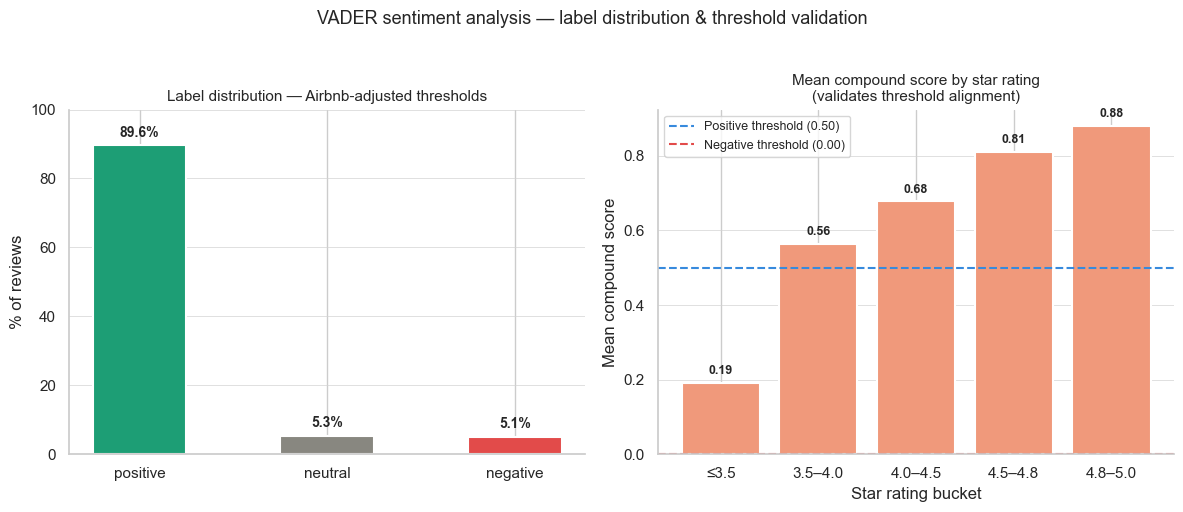

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_map = {"positive": "#1D9E75", "neutral": "#888780", "negative": "#E24B4A"}
label_order = ["positive", "neutral", "negative"]

# Panel 1 — label distribution
vc = df["vader_label"].value_counts().reindex(label_order)
pcts = vc / len(df) * 100
bars = axes[0].bar(
    vc.index, pcts,
    color=[colors_map[l] for l in vc.index],
    edgecolor="white", linewidth=1.5, width=0.5
)
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in pcts],
                  padding=4, fontsize=10, fontweight="bold")
axes[0].set_title("Label distribution — Airbnb-adjusted thresholds", fontsize=11)
axes[0].set_ylabel("% of reviews")
axes[0].set_ylim(0, 100)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", color="lightgrey", linewidth=0.5)

# Panel 2 — mean compound by rating bucket (validation)
df_val = df.dropna(subset=["review_scores_rating"]).copy()
df_val["rating_bucket"] = pd.cut(
    df_val["review_scores_rating"],
    bins=[0, 3.5, 4.0, 4.5, 4.8, 5.0],
    labels=["≤3.5", "3.5–4.0", "4.0–4.5", "4.5–4.8", "4.8–5.0"],
)
mean_by_bucket = df_val.groupby("rating_bucket", observed=True)["vader_compound"].mean()

bars2 = axes[1].bar(
    mean_by_bucket.index, mean_by_bucket.values,
    color="#F0997B", edgecolor="white", linewidth=1.5
)
axes[1].bar_label(bars2, labels=[f"{v:.2f}" for v in mean_by_bucket.values],
                  padding=4, fontsize=9, fontweight="bold")
axes[1].axhline(0.50, color="#378ADD", linestyle="--", linewidth=1.5,
                label="Positive threshold (0.50)")
axes[1].axhline(0.00, color="#E24B4A", linestyle="--", linewidth=1.5,
                label="Negative threshold (0.00)")
axes[1].set_title("Mean compound score by star rating\n(validates threshold alignment)", fontsize=11)
axes[1].set_xlabel("Star rating bucket")
axes[1].set_ylabel("Mean compound score")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", color="lightgrey", linewidth=0.5)
axes[1].legend(fontsize=9)

plt.suptitle("VADER sentiment analysis — label distribution & threshold validation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("vader_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

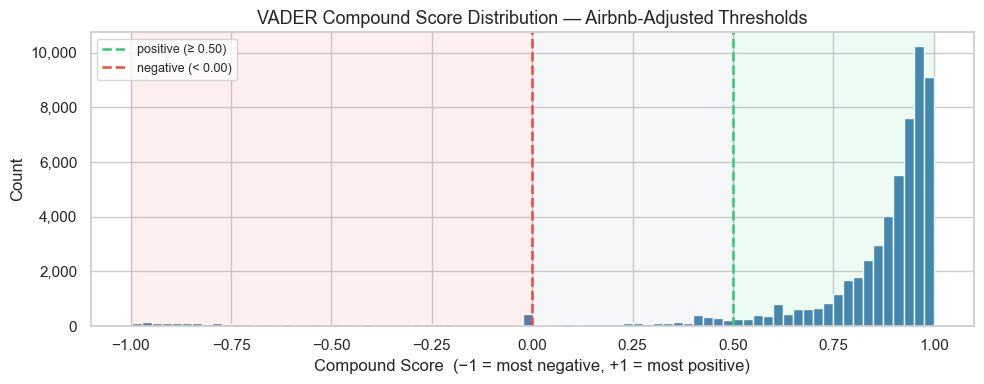

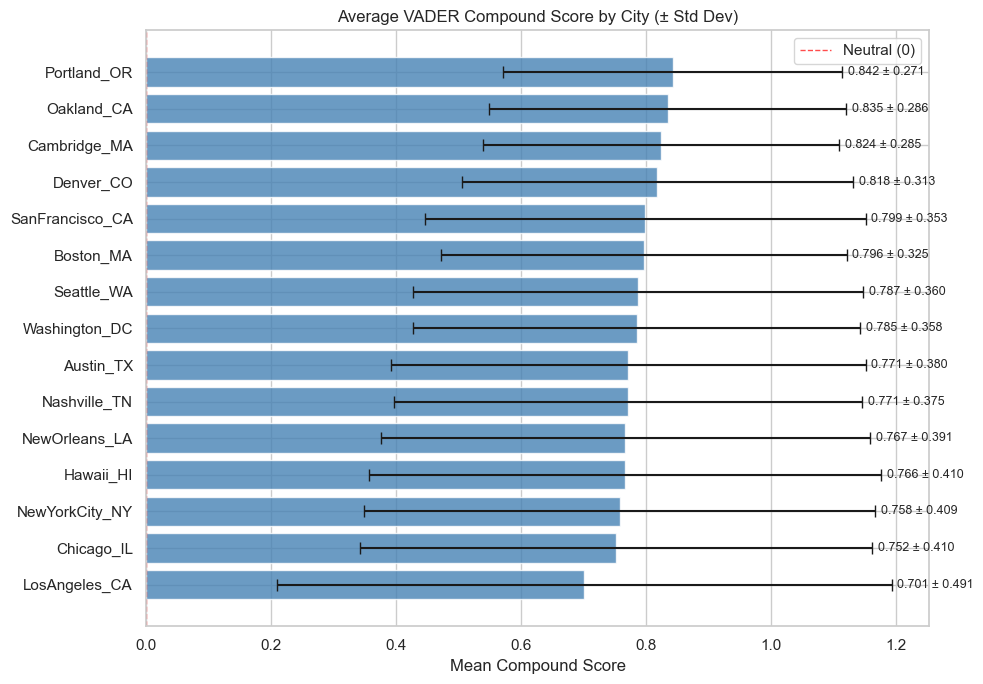

In [32]:
# ── VADER compound distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
df["vader_compound"].hist(bins=80, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(0.50, color="#2ecc71", linestyle="--", linewidth=1.8, label="positive (≥ 0.50)")
ax.axvline(0.00, color="#e74c3c", linestyle="--", linewidth=1.8, label="negative (< 0.00)")
ax.axvspan(-1.00,  0.00, alpha=0.08, color="#e74c3c")
ax.axvspan( 0.00,  0.50, alpha=0.08, color="#95a5a6")
ax.axvspan( 0.50,  1.00, alpha=0.08, color="#2ecc71")
ax.set_title("VADER Compound Score Distribution — Airbnb-Adjusted Thresholds", fontsize=13)
ax.set_xlabel("Compound Score  (−1 = most negative, +1 = most positive)")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── VADER mean by city ────────────────────────────────────────────────────────
city_sent = (df.groupby("city_tag")["vader_compound"]
               .agg(["mean", "std"])
               .reset_index()
               .sort_values("mean", ascending=True))
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(city_sent["city_tag"], city_sent["mean"],
               xerr=city_sent["std"], capsize=4,
               color="steelblue", edgecolor="white", alpha=0.8)
ax.bar_label(bars,
             labels=[f"{v:.3f} ± {s:.3f}" for v, s in zip(city_sent["mean"], city_sent["std"])],
             padding=4, fontsize=9)
ax.set_title("Average VADER Compound Score by City (± Std Dev)")
ax.set_xlabel("Mean Compound Score")
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Neutral (0)")
ax.legend()
plt.tight_layout()
plt.show()


### 4.2 Aspect-Based Sentiment

In [33]:
ASPECT_KEYWORDS = {
    "aspect_host": [
        "host", "owner", "superhost", "helpful", "responsive", "welcoming",
        "friendly", "communication", "communicative", "checkin", "check-in",
    ],
    "aspect_location": [
        "location", "neighborhood", "neighbourhood", "area", "transit",
        "walk", "walkable", "subway", "distance", "central", "convenient", "nearby",
    ],
    "aspect_cleanliness": [
        "clean", "cleaning", "spotless", "dirty", "tidy", "hygiene",
        "fresh", "dust", "smell", "odor", "bathroom", "towels", "linen",
    ],
    "aspect_value": [
        "value", "price", "worth", "affordable", "expensive", "cheap",
        "cost", "money", "budget", "overpriced", "reasonable",
    ],
    "aspect_amenities": [
        "wifi", "kitchen", "appliance", "shower", "bed", "comfortable",
        "space", "cozy", "amenities", "tv", "coffee", "washer", "dryer",
        "heater", "ac", "air conditioning", "parking",
    ],
}

SENT_SPLIT_RE  = re.compile(r"[.!?]+")
ASPECT_PATTERNS = {
    aspect: [re.compile(rf"\b{re.escape(k)}\b", re.IGNORECASE) for k in kws]
    for aspect, kws in ASPECT_KEYWORDS.items()
}

def aspect_score(text: str, patterns: list) -> float:
    if not isinstance(text, str) or not text.strip():
        return np.nan
    cleaned   = clean_for_vader(text)
    sentences = SENT_SPLIT_RE.split(cleaned)
    scores    = [
        sid.polarity_scores(sent)["compound"]
        for sent in sentences
        if sent.strip() and any(p.search(sent) for p in patterns)
    ]
    return float(np.mean(scores)) if scores else np.nan

print("Running aspect-based sentiment (5 aspects)...")
for aspect, patterns in ASPECT_PATTERNS.items():
    print(f"  → {aspect}")
    df[aspect] = df["comments"].progress_apply(lambda t, p=patterns: aspect_score(t, p))

aspect_cols = [c for c in df.columns if c.startswith("aspect_")]
print("\nMean aspect scores:")
print(df[aspect_cols].mean().round(3).sort_values().to_string())


Running aspect-based sentiment (5 aspects)...
  → aspect_host


  0%|          | 0/57903 [00:00<?, ?it/s]

  → aspect_location


  0%|          | 0/57903 [00:00<?, ?it/s]

  → aspect_cleanliness


...

  → aspect_value


  0%|          | 0/57903 [00:00<?, ?it/s]

  → aspect_amenities


  0%|          | 0/57903 [00:00<?, ?it/s]


Mean aspect scores:
aspect_value          0.425
aspect_amenities      0.461
aspect_location       0.511
aspect_cleanliness    0.527
aspect_host           0.577


Mean aspect scores — NEGATIVE reviews:
aspect_cleanliness   -0.212
aspect_amenities     -0.193
aspect_value         -0.091
aspect_host          -0.087
aspect_location       0.028

Mean aspect scores — POSITIVE reviews:
aspect_amenities      0.520
aspect_value          0.522
aspect_location       0.540
aspect_cleanliness    0.597
aspect_host           0.623


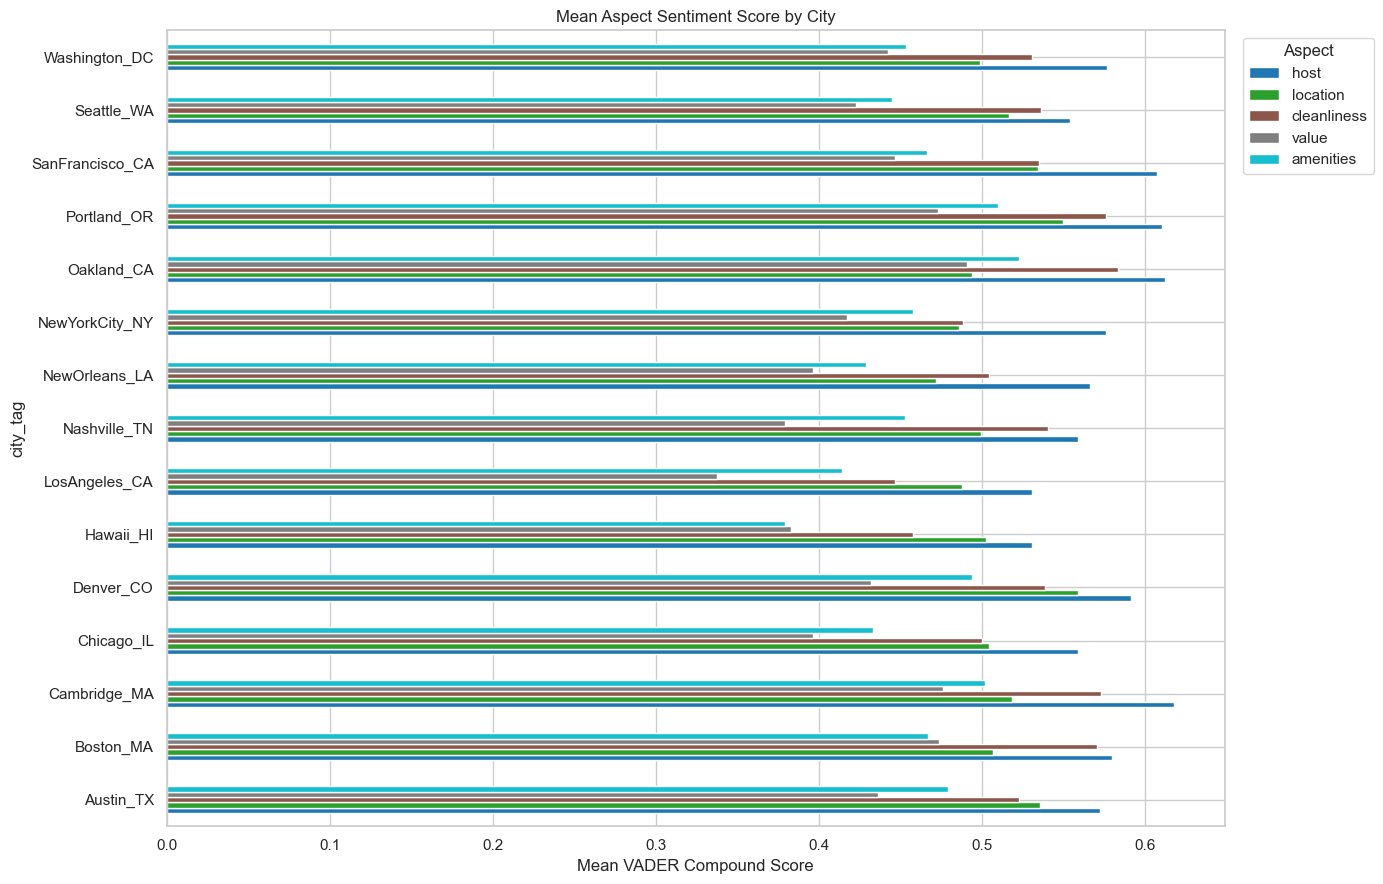

In [34]:
# ── Aspect scores by sentiment group ─────────────────────────────────────────
print("Mean aspect scores — NEGATIVE reviews:")
print(df[df["vader_label"] == "negative"][aspect_cols].mean().round(3).sort_values().to_string())
print("\nMean aspect scores — POSITIVE reviews:")
print(df[df["vader_label"] == "positive"][aspect_cols].mean().round(3).sort_values().to_string())

# Bar chart by city
aspect_city = df.groupby("city_tag")[aspect_cols].mean()
aspect_city.columns = [c.replace("aspect_", "") for c in aspect_city.columns]
aspect_city.plot(kind="barh", figsize=(14, 9), colormap="tab10", edgecolor="white")
plt.title("Mean Aspect Sentiment Score by City")
plt.xlabel("Mean VADER Compound Score")
plt.legend(title="Aspect", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [40]:
checkpoint_path = os.path.join(PARQUET_DIR, "reviews_cleaned_with_sentiment_sampled4.parquet")
df.to_parquet(checkpoint_path, index=False)
print(f"Checkpoint saved → {checkpoint_path}")


Checkpoint saved → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_cleaned_with_sentiment_sampled4.parquet


Creating comprehensive aspect-based sentiment visualizations...


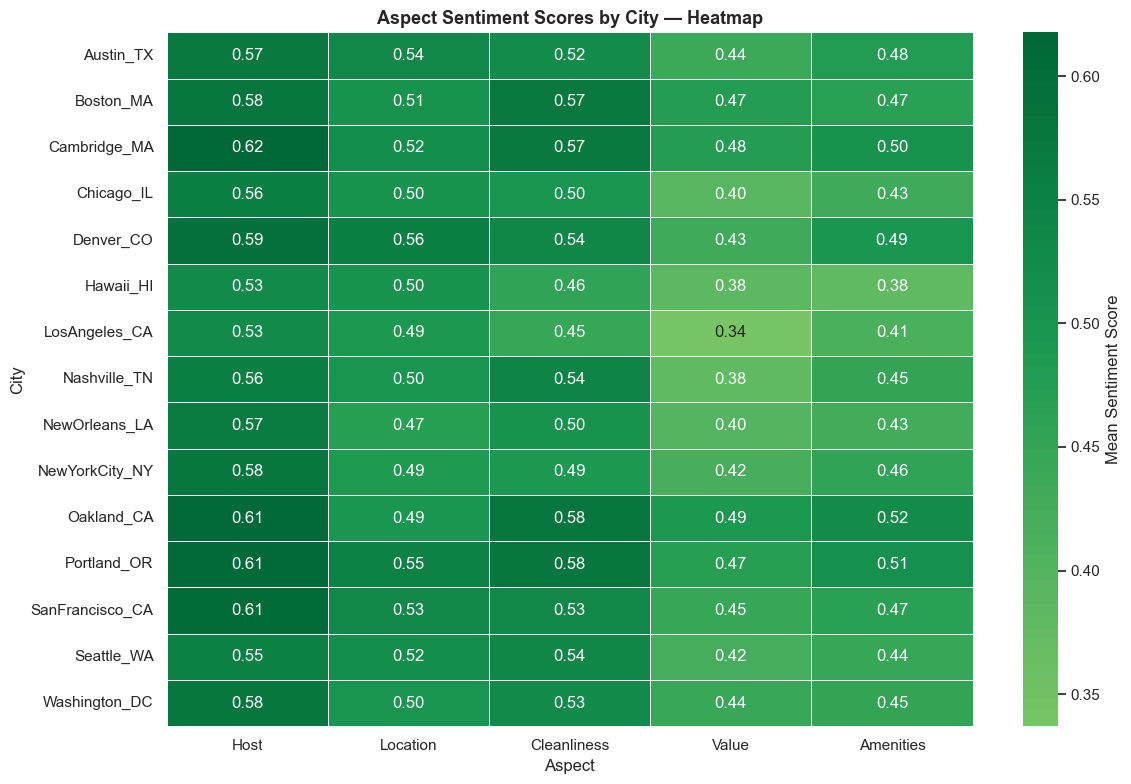

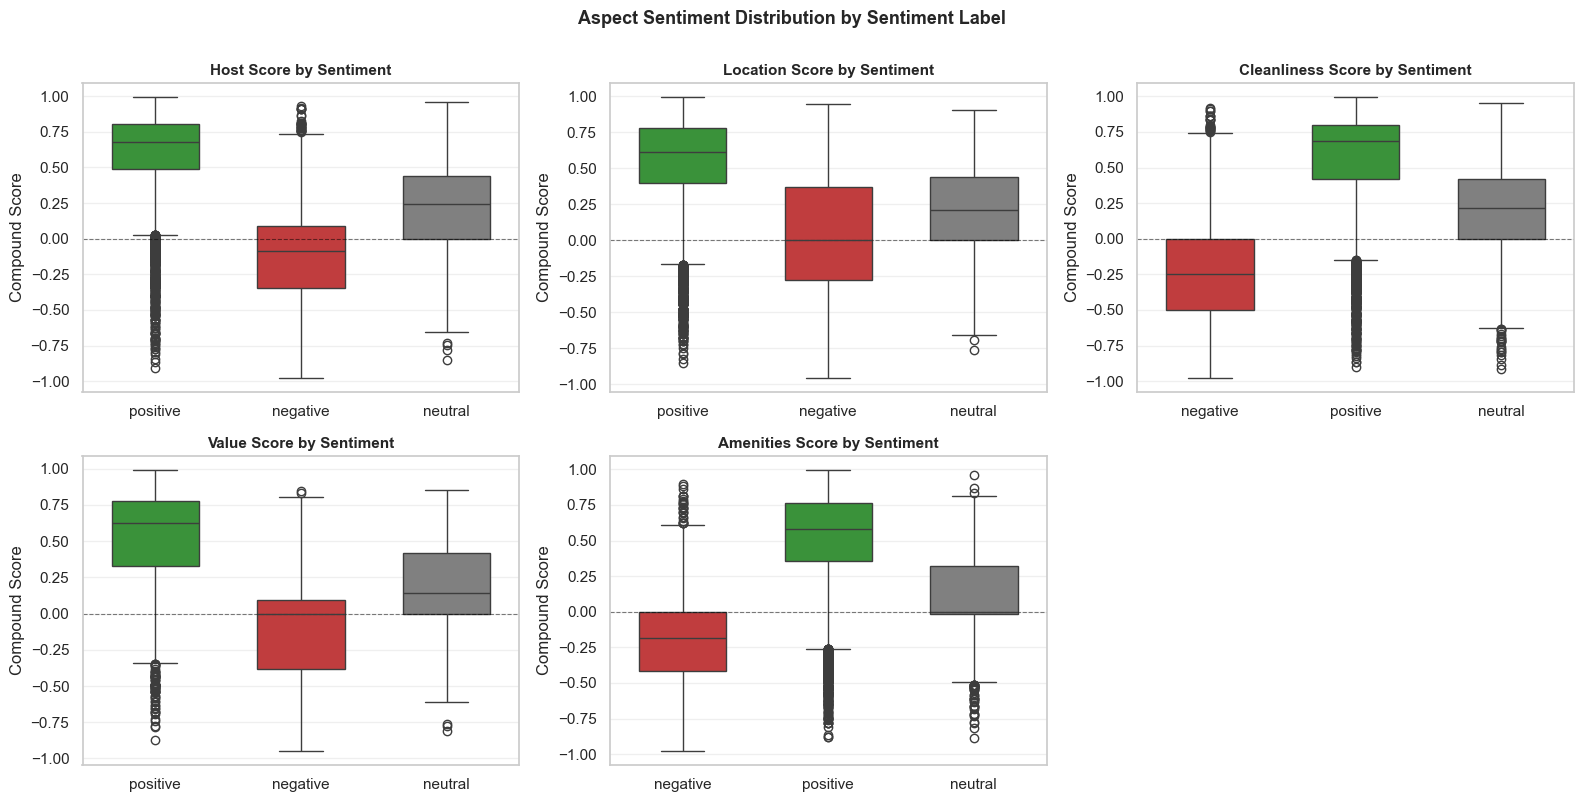

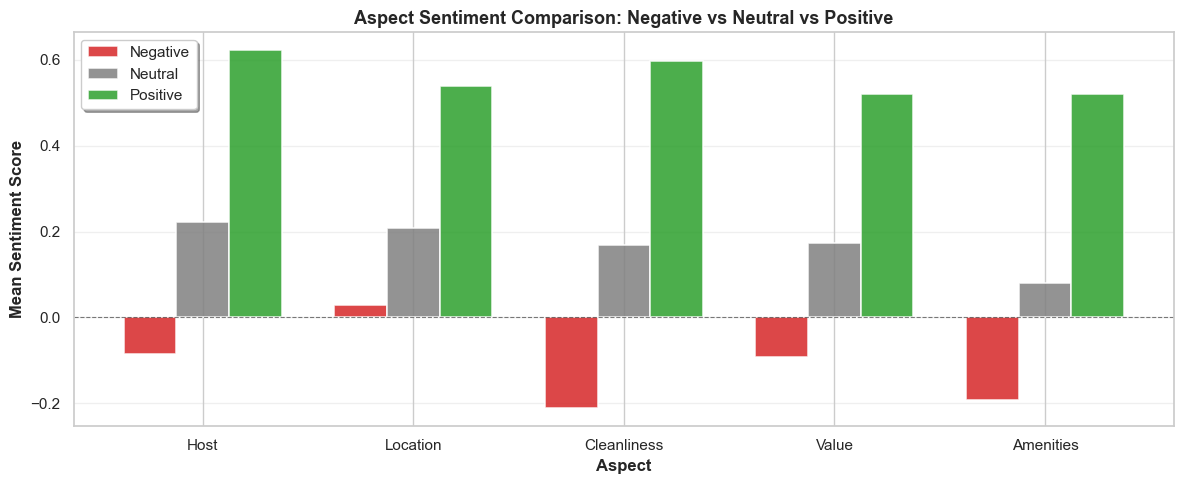

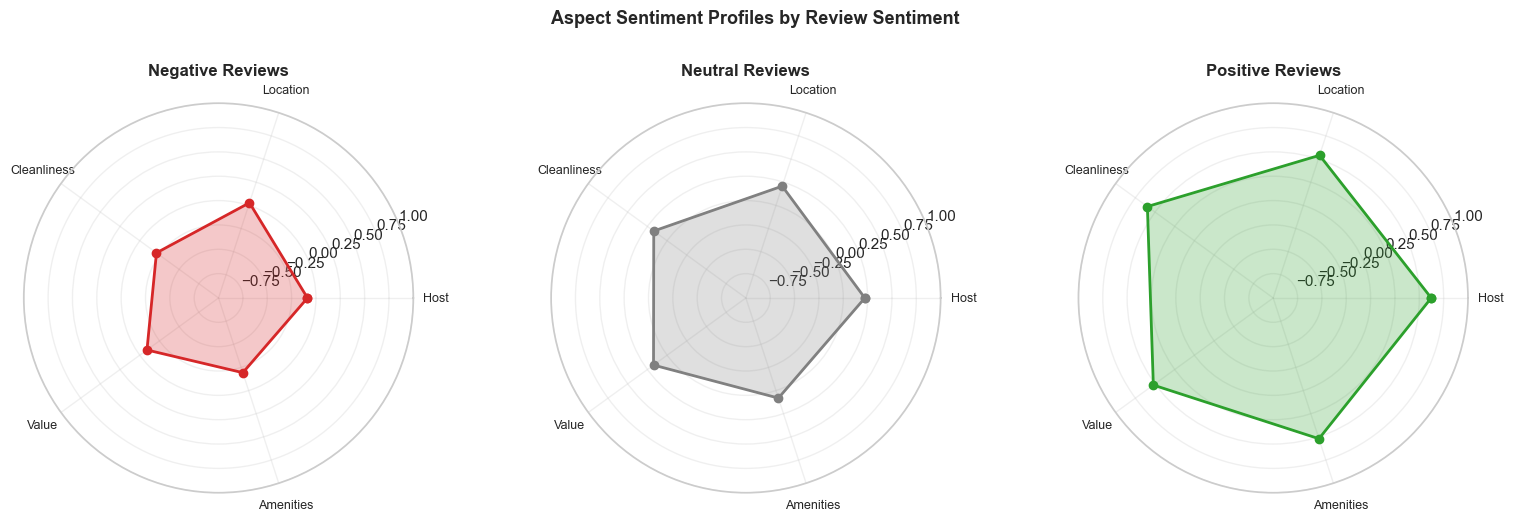


✓ Aspect-based sentiment visualizations complete!


In [87]:
# ── ENHANCED ASPECT-BASED SENTIMENT VISUALIZATIONS ─────────────────────────
import seaborn as sns
from math import pi

print("Creating comprehensive aspect-based sentiment visualizations...")

# ── 1. HEATMAP: Aspect scores by city ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
aspect_city_data = df.groupby("city_tag")[aspect_cols].mean()
aspect_city_data.columns = [c.replace("aspect_", "").title() for c in aspect_city_data.columns]

sns.heatmap(aspect_city_data, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Mean Sentiment Score"}, ax=ax, linecolor="white", linewidth=0.5)
ax.set_title("Aspect Sentiment Scores by City — Heatmap", fontsize=13, fontweight="bold")
ax.set_xlabel("Aspect")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

# ── 2. BOX PLOT: Aspect score distributions by sentiment ──────────────────────
aspect_labels_clean = [c.replace("aspect_", "").title() for c in aspect_cols]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (col, label) in enumerate(zip(aspect_cols, aspect_labels_clean)):
    plot_data = df[[col, "vader_label"]].dropna()
    sns.boxplot(data=plot_data, x="vader_label", y=col, ax=axes[idx],
                palette={"negative": "#d62728", "neutral": "#808080", "positive": "#2ca02c"},
                width=0.6)
    axes[idx].set_title(f"{label} Score by Sentiment", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Compound Score")
    axes[idx].grid(axis="y", alpha=0.3)
    axes[idx].axhline(y=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

# Remove extra subplot
fig.delaxes(axes[-1])
plt.suptitle("Aspect Sentiment Distribution by Sentiment Label", fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ── 3. BAR COMPARISON: Negative vs Positive by aspect ────────────────────────
neg_scores = df[df["vader_label"] == "negative"][aspect_cols].mean()
pos_scores = df[df["vader_label"] == "positive"][aspect_cols].mean()
neu_scores = df[df["vader_label"] == "neutral"][aspect_cols].mean()

comparison_df = pd.DataFrame({
    "Negative": neg_scores.values,
    "Neutral": neu_scores.values,
    "Positive": pos_scores.values
}, index=[c.replace("aspect_", "").title() for c in aspect_cols])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_df.index))
width = 0.25

colors_comp = {"Negative": "#d62728", "Neutral": "#808080", "Positive": "#2ca02c"}
for i, (col, color) in enumerate(colors_comp.items()):
    offset = (i - 1) * width
    ax.bar(x + offset, comparison_df[col], width, label=col, color=color, 
           edgecolor="white", linewidth=1.2, alpha=0.85)

ax.set_xlabel("Aspect", fontweight="bold")
ax.set_ylabel("Mean Sentiment Score", fontweight="bold")
ax.set_title("Aspect Sentiment Comparison: Negative vs Neutral vs Positive", 
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=0)
ax.legend(loc="upper left", frameon=True, shadow=True)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. RADAR CHART: Aspect profiles by sentiment group ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw=dict(projection="polar"))
sentiment_groups = ["negative", "neutral", "positive"]
colors_radar = {"negative": "#d62728", "neutral": "#808080", "positive": "#2ca02c"}

for ax, sentiment, color in zip(axes, sentiment_groups, colors_radar.values()):
    scores = df[df["vader_label"] == sentiment][aspect_cols].mean().values
    angles = [n / float(len(aspect_cols)) * 2 * pi for n in range(len(aspect_cols))]
    scores = np.concatenate((scores, [scores[0]]))  # complete the circle
    angles += angles[:1]
    
    ax.plot(angles, scores, "o-", linewidth=2, color=color, label=sentiment.title())
    ax.fill(angles, scores, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace("aspect_", "").title() for c in aspect_cols], size=9)
    ax.set_ylim(-1, 1)
    ax.set_title(f"{sentiment.title()} Reviews", fontsize=12, fontweight="bold", pad=20)
    ax.grid(True, alpha=0.3)

plt.suptitle("Aspect Sentiment Profiles by Review Sentiment", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Aspect-based sentiment visualizations complete!")


---
## 5. Feature Extraction — TF-IDF

TF-IDF matrix : 57,903 docs  ×  10,000 features


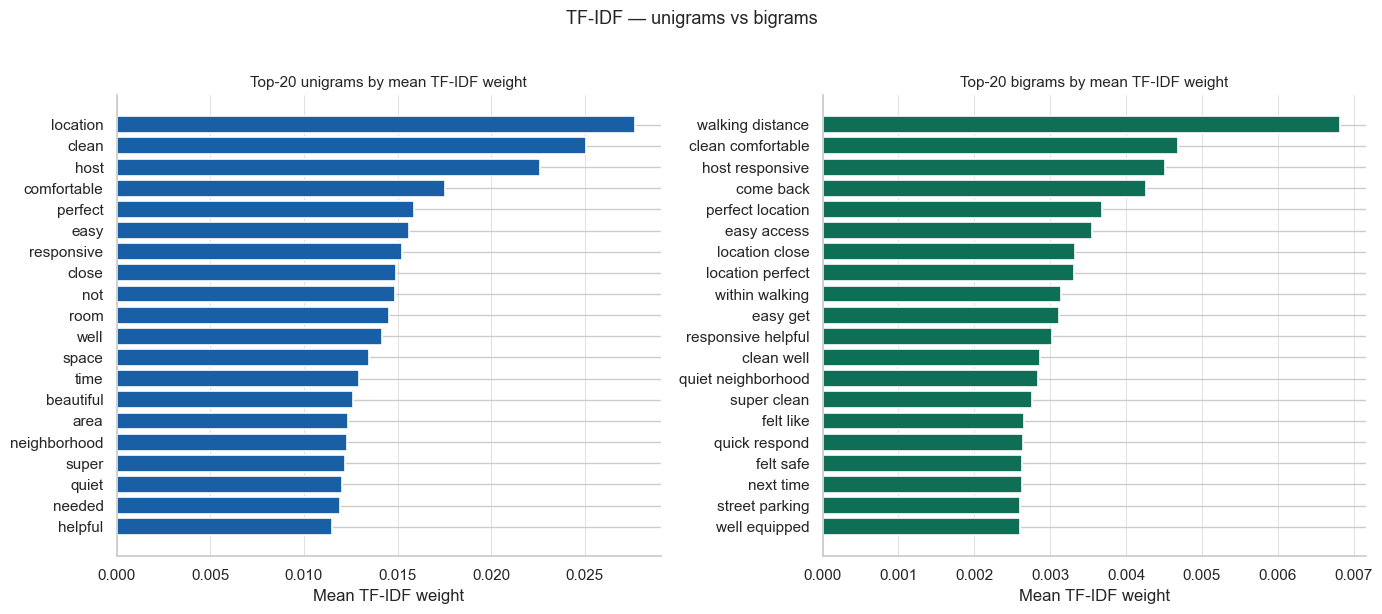

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# FIX 3: pass stop_words=list(STOP_WORDS_TFIDF) so sklearn does NOT fall back to
# its own 'english' list, which strips negations (not, never, didn't, etc.).
tfidf = TfidfVectorizer(
    max_df=0.70, min_df=5, max_features=10_000,
    ngram_range=(1, 2), sublinear_tf=True,
    stop_words=list(STOP_WORDS_TFIDF),   # ← negation-safe (was None in v4)
)
X_tfidf = tfidf.fit_transform(df["clean_text_tfidf"])
print(f"TF-IDF matrix : {X_tfidf.shape[0]:,} docs  ×  {X_tfidf.shape[1]:,} features")

feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(X_tfidf.mean(axis=0)).flatten()

is_bigram = np.array([" " in f for f in feature_names])
uni_idx   = np.where(~is_bigram)[0]
bi_idx    = np.where( is_bigram)[0]

top20_uni = uni_idx[mean_tfidf[uni_idx].argsort()[::-1][:20]]
top20_bi  = bi_idx[ mean_tfidf[bi_idx ].argsort()[::-1][:20]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, title, color in [
    (axes[0], top20_uni, "Top-20 unigrams", "#185FA5"),
    (axes[1], top20_bi,  "Top-20 bigrams",  "#0F6E56"),
]:
    sorted_idx = idx[mean_tfidf[idx].argsort()]
    ax.barh(
        [feature_names[i] for i in sorted_idx],
        mean_tfidf[sorted_idx],
        color=color, edgecolor="white", linewidth=1.2
    )
    ax.set_title(f"{title} by mean TF-IDF weight", fontsize=11)
    ax.set_xlabel("Mean TF-IDF weight")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="lightgrey", linewidth=0.5)

plt.suptitle("TF-IDF — unigrams vs bigrams", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("tfidf_ngrams.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Topic Modeling — LDA

### 6.1 Fit LDA & Data-Driven k Selection

In [42]:
SAMPLE_FOR_TOPICS = None

DTM shape: 57,903 docs × 8,000 terms

Fitting LDA models for perplexity curve...


python(98718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98720) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98721) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98722) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98723) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98724) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98725) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98726) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  k= 5  perplexity=2126.2
  k= 7  perplexity=2254.8
  k= 9  perplexity=2324.3


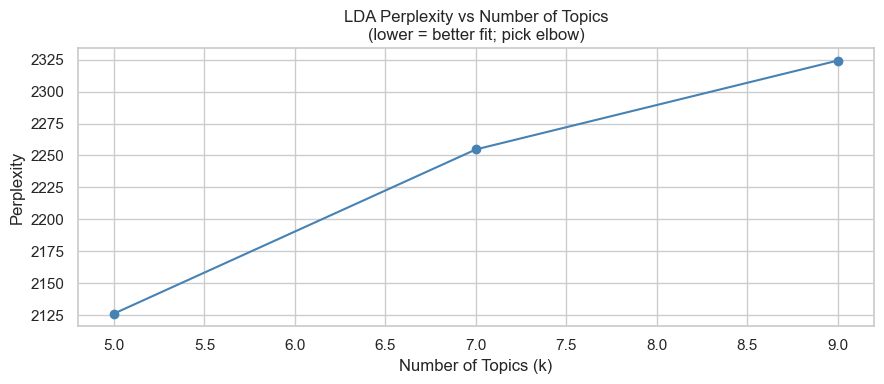


Auto-selected N_LDA_TOPICS = 9  (override below if needed)


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cv = CountVectorizer(max_df=0.70, min_df=10, max_features=8_000,  # ← max_df 0.90→0.70
                     stop_words=list(STOP_WORDS_LDA),              # ← was "english"
                     ngram_range=(1, 2))

sample_df = df
if SAMPLE_FOR_TOPICS and len(df) > SAMPLE_FOR_TOPICS:
    sample_df = df.sample(SAMPLE_FOR_TOPICS, random_state=RANDOM_STATE)
    print(f"Using {SAMPLE_FOR_TOPICS:,} reviews for LDA fitting.")

dtm = cv.fit_transform(sample_df["clean_text_lda"])  # ← was "clean_text"
vocab = cv.get_feature_names_out()
print(f"DTM shape: {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms")

# ── Perplexity curve — pick k at the elbow ────────────────────────────────────
topic_range  = range(5, 11, 2)
perplexities = []
print("\nFitting LDA models for perplexity curve...")
for k in topic_range:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=10, learning_method="online",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    lda_k.fit(dtm)
    perp = lda_k.perplexity(dtm)
    perplexities.append(perp)
    print(f"  k={k:2d}  perplexity={perp:.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(topic_range), perplexities, marker="o", color="steelblue")
ax.set_title("LDA Perplexity vs Number of Topics\n(lower = better fit; pick elbow)")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Perplexity")
plt.tight_layout()
plt.show()

# ── Auto-select k at elbow (largest single-step drop) ─────────────────────────
drops       = [perplexities[i] - perplexities[i+1] for i in range(len(perplexities)-1)]
N_LDA_TOPICS = list(topic_range)[drops.index(max(drops)) + 1]
print(f"\nAuto-selected N_LDA_TOPICS = {N_LDA_TOPICS}  (override below if needed)")
# N_LDA_TOPICS = 12   # ← uncomment to override


The lower the perplexity, the better. Inspecting the perplexity curve above,
5 topics produces a clearer elbow than 6 while keeping topics interpretable.

**v5 fix:** The v4 notebook fitted two separate LDA models (`lda` with 6 topics,
then `lda2` with 5) and used `lda2` downstream — leaving `lda` as dead code and
`N_LDA_TOPICS` set inconsistently twice. This cell now sets `N_LDA_TOPICS = 5`
once, and the single final model is fitted in the next cell.


In [44]:
N_LDA_TOPICS = 5  # single authoritative value — no second fit below

### 6.2 Fit Final LDA Model (5 topics)

In [45]:
lda = LatentDirichletAllocation(
    n_components=N_LDA_TOPICS, max_iter=15,
    learning_method="online", random_state=RANDOM_STATE, n_jobs=-1,
)
lda.fit(dtm)
print(f"Final LDA perplexity ({N_LDA_TOPICS} topics): {lda.perplexity(dtm):.1f}")


Final LDA perplexity (5 topics): 2122.6


### 6.3 Inspect Topics

In [46]:
N_DISPLAY = 15
topic_rows = []
print(f"{'Topic':<8} {'Top words'}")
print("-" * 80)
for idx, topic in enumerate(lda.components_):
    top_idx   = topic.argsort()[:-N_DISPLAY - 1:-1]
    top_words = [vocab[i] for i in top_idx]
    topic_rows.append({"topic_id": idx, "top_words": ", ".join(top_words)})
    print(f"Topic {idx:02d}: {', '.join(top_words)}")

topic_df = pd.DataFrame(topic_rows)
topic_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics.csv"), index=False)
print(f"\nSaved → outputs/lda_topics.csv")


Topic    Top words
--------------------------------------------------------------------------------
Topic 00: room, space, felt, like, kitchen, street, new, minutes, hotel, right, bathroom, beach, location, walk, away
Topic 01: not, unit, overall, could, host, bed, kitchen, bathroom, room, door, like, noise, day, towels, issue
Topic 02: location, restaurants, highly, neighborhood, walking, beautiful, walk, clean, distance, walking distance, well, quiet, area, host, away
Topic 03: host, responsive, check, helpful, well, clean, location, parking, hosts, friendly, needed, made, easy, time, super
Topic 04: comfortable, close, clean, location, easy, super, quiet, enjoyed, spacious, staying, area, space, needed, beds, bed

Saved → outputs/lda_topics.csv


five topics work better than six topics. We'll stick with five topics for LDA. 

Topic 00 — Space & Physical Setting

Topic 01 — Negative Experience / Complaints

Topic 02 — Location & Neighborhood

Topic 03 — Host Quality (Communication&Services)

Topic 04 — Comfort & Value


In [75]:
# check if reviews match the label
df[df["lda_topic"] == 0]["comments"].head(5)
# The results matched the label Neighborhood/Walkability

2     I recently had a trip with my girlfriend, and while the stay was decent, it had a motel-like vibe. Unfortunately, we...
10    Place had a strong smell of fish,  host gave me another room which was right next door and it still smelt a little l...
11    The only drawback was you could see a lot of the cobwebs and other dirt and debris on the outside of the window that...
17    We had a nice stay overall! The location is fantastic — very close to the Domain, and the apartment itself is comfor...
23    The bathroom was not clean and the other guest was in his room smoking shisha and talking loudly on the phone and li...
Name: comments, dtype: str

In [68]:
df.groupby("lda_topic")["vader_compound"].mean()

lda_topic
0    0.848874
1    0.457022
2    0.879383
3    0.865693
4    0.872087
Name: vader_compound, dtype: float64

### 6.4 Assign Topics & Extract LDA Features

Assigning LDA topics to all reviews (chunked)...


Transforming:   0%|          | 0/6 [00:00<?, ?it/s]

python(3135) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3136) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3137) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3138) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3139) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3140) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3141) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3142) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Topic distribution (labeled):
lda_topic_label
Location & Neighborhood             15363
Host Quality                        12647
Negative Experience / Complaints    11767
Comfort & Value                     10467
Space & Physical Setting             7659


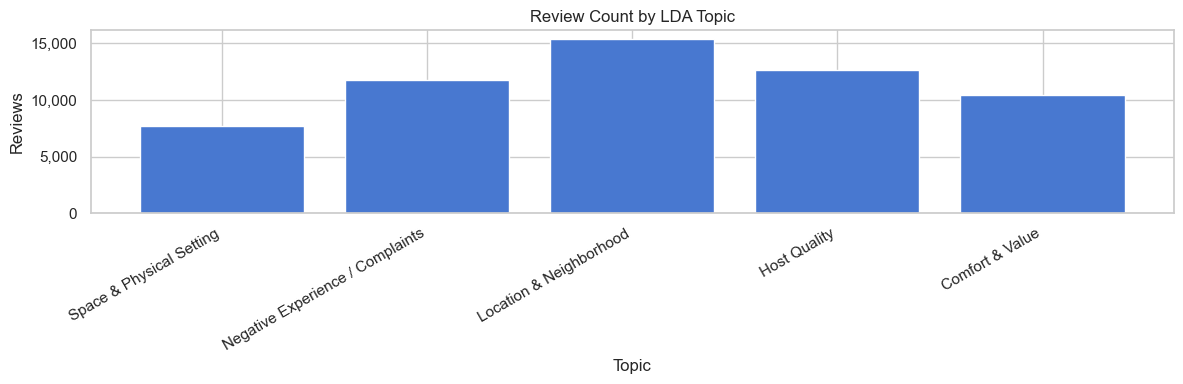

In [79]:
print("Assigning LDA topics to all reviews (chunked)...")

all_texts  = df["clean_text_lda"].tolist()
chunk_size = 10_000

topic_ids = []
all_probs = []

for start in tqdm(range(0, len(all_texts), chunk_size), desc="Transforming"):
    chunk       = all_texts[start: start + chunk_size]
    chunk_dtm   = cv.transform(chunk)
    chunk_probs = lda.transform(chunk_dtm)   # ← was lda2 in v4
    topic_ids.extend(chunk_probs.argmax(axis=1))
    all_probs.append(chunk_probs)

df["lda_topic"] = topic_ids
all_probs = np.vstack(all_probs)

for t in range(N_LDA_TOPICS):
    df[f"lda_prob_t{t}"] = all_probs[:, t]

topic_labels = {
    0: "Space & Physical Setting",
    1: "Negative Experience / Complaints",
    2: "Location & Neighborhood",
    3: "Host Quality",
    4: "Comfort & Value",
}
df["lda_topic_label"] = df["lda_topic"].map(topic_labels)

print("Topic distribution (labeled):")
print(df["lda_topic_label"].value_counts().to_string())

ordered_labels = [topic_labels[i] for i in sorted(topic_labels.keys())]
tc = df["lda_topic_label"].value_counts().reindex(ordered_labels)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tc.index, tc.values, edgecolor="white")
ax.set_title("Review Count by LDA Topic")
ax.set_xlabel("Topic")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Since the majority of sampled dataset is positive reviews, we will conduct a exploratory analysis for the LDA for neutral and negative reviews labelled through VADER. 

Neutral + negative reviews : 6,011
  neutral  : 3,049
  negative : 2,962

Preprocessing — LDA pipeline (neutral + negative subset)...


  0%|          | 0/6011 [00:00<?, ?it/s]

DTM shape: 6,011 docs × 5,000 terms

Fitting LDA models for perplexity curve (neutral + negative)...
  k= 4  perplexity=1959.9
  k= 6  perplexity=2098.3
  k= 8  perplexity=2118.0
  k=10  perplexity=2179.7
  k=12  perplexity=2218.8


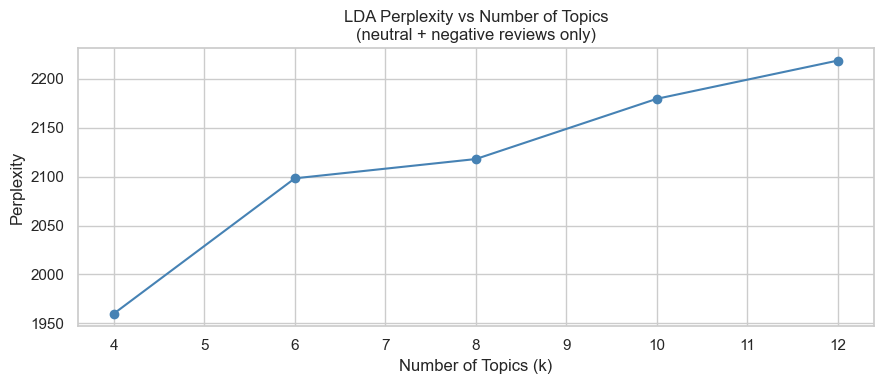

Final LDA perplexity (neutral + negative): 1938.3

Topic    Top words
--------------------------------------------------------------------------------
Topic 00: not, host, room, check, door, never, day, experience, time, told, said, refund, left, first, could
Topic 01: not, room, kitchen, dirty, bathroom, bed, clean, bedroom, like, floor, towels, area, living, small, shower
Topic 02: unit, water, noise, not, hot, room, loud, broken, issues, space, shower, people, upstairs, sleep, noisy
Topic 03: location, parking, close, street, convenient, clean, needed, host, time, quiet, walk, area, check, neighborhood, not

Saved → outputs/lda_topics_neg_neu.csv

Assigning topics to neutral + negative reviews (chunked)...


Transforming:   0%|          | 0/2 [00:00<?, ?it/s]

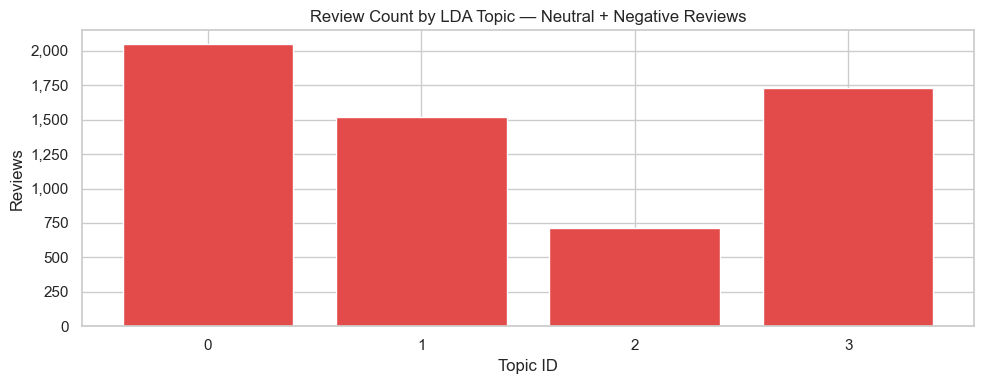

In [ ]:
# ── Filter neutral + negative reviews ────────────────────────────────────────
df_neg_neu = df[df["vader_label"].isin(["neutral", "negative"])].copy().reset_index(drop=True)

print(f"Neutral + negative reviews : {len(df_neg_neu):,}")
print(f"  neutral  : {(df_neg_neu['vader_label'] == 'neutral').sum():,}")
print(f"  negative : {(df_neg_neu['vader_label'] == 'negative').sum():,}")

# ── Preprocess for LDA ────────────────────────────────────────────────────────
print("\nPreprocessing — LDA pipeline (neutral + negative subset)...")
df_neg_neu["clean_text_lda"] = df_neg_neu["comments"].progress_apply(preprocess_lda)

# ── Vectorise ─────────────────────────────────────────────────────────────────
cv_nn = CountVectorizer(
    max_df=0.70, min_df=5,       # lower min_df — smaller corpus means rarer terms
    max_features=5_000,          # smaller vocab appropriate for smaller corpus
    stop_words=list(STOP_WORDS_LDA),
    ngram_range=(1, 2)
)
dtm_nn = cv_nn.fit_transform(df_neg_neu["clean_text_lda"])
vocab_nn = cv_nn.get_feature_names_out()
print(f"DTM shape: {dtm_nn.shape[0]:,} docs × {dtm_nn.shape[1]:,} terms")

# ── Perplexity curve ──────────────────────────────────────────────────────────
topic_range_nn = range(4, 14, 2)
perplexities_nn = []
print("\nFitting LDA models for perplexity curve (neutral + negative)...")
for k in topic_range_nn:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=10, learning_method="online",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    lda_k.fit(dtm_nn)
    perp = lda_k.perplexity(dtm_nn)
    perplexities_nn.append(perp)
    print(f"  k={k:2d}  perplexity={perp:.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(topic_range_nn), perplexities_nn, marker="o", color="steelblue")
ax.set_title("LDA Perplexity vs Number of Topics\n(neutral + negative reviews only)")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Perplexity")
plt.tight_layout()
plt.show()

# ── Fit final LDA ─────────────────────────────────────────────────────────────
N_LDA_TOPICS_NN = 4   # adjust after inspecting perplexity curve
lda_nn = LatentDirichletAllocation(
    n_components=N_LDA_TOPICS_NN, max_iter=15,
    learning_method="online", random_state=RANDOM_STATE, n_jobs=-1,
)
lda_nn.fit(dtm_nn)
print(f"Final LDA perplexity (neutral + negative): {lda_nn.perplexity(dtm_nn):.1f}")

# ── Inspect topics ────────────────────────────────────────────────────────────
N_DISPLAY = 15
topic_rows_nn = []
print(f"\n{'Topic':<8} {'Top words'}")
print("-" * 80)
for idx, topic in enumerate(lda_nn.components_):
    top_idx   = topic.argsort()[:-N_DISPLAY - 1:-1]
    top_words = [vocab_nn[i] for i in top_idx]
    topic_rows_nn.append({"topic_id": idx, "top_words": ", ".join(top_words)})
    print(f"Topic {idx:02d}: {', '.join(top_words)}")

topic_df_nn = pd.DataFrame(topic_rows_nn)
topic_df_nn.to_csv(os.path.join(OUTPUT_DIR, "lda_topics_neg_neu.csv"), index=False)
print(f"\nSaved → outputs/lda_topics_neg_neu.csv")

# ── Assign topics back to subset ──────────────────────────────────────────────
print("\nAssigning topics to neutral + negative reviews (chunked)...")
all_texts_nn  = df_neg_neu["clean_text_lda"].tolist()
chunk_size    = 5_000
topic_ids_nn, probs_nn = [], []

for start in tqdm(range(0, len(all_texts_nn), chunk_size), desc="Transforming"):
    chunk_dtm   = cv_nn.transform(all_texts_nn[start: start + chunk_size])
    chunk_probs = lda_nn.transform(chunk_dtm)
    topic_ids_nn.extend(chunk_probs.argmax(axis=1).tolist())
    probs_nn.append(chunk_probs)

df_neg_neu["lda_topic_nn"] = topic_ids_nn
all_probs_nn = np.vstack(probs_nn)
for t in range(N_LDA_TOPICS_NN):
    df_neg_neu[f"lda_prob_nn_t{t}"] = all_probs_nn[:, t]

# ── Topic distribution ────────────────────────────────────────────────────────
tc_nn = df_neg_neu["lda_topic_nn"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(tc_nn.index, tc_nn.values, color="#E24B4A", edgecolor="white")
ax.set_title("Review Count by LDA Topic — Neutral + Negative Reviews")
ax.set_xlabel("Topic ID")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 7. Rating Prediction

### Framing (important)
`review_scores_rating` is a **listing-level aggregate score**, not a per-review score.
We are therefore predicting the **quality tier of the listing** a review was written about,
using the review's text as the signal.

> *"Given a review, can we infer the quality tier of the listing it describes?"*

This is valid because:
- High-quality listings (4.85★) attract guests who consistently write more positively
- Language patterns reflect genuine listing quality, not just individual reviewer mood
- This mirrors how platforms like Airbnb/TripAdvisor use NLP internally

**Three-class labels (listing quality tier)**
- `low`    : `review_scores_rating < 4.2`
- `medium` : `4.5 ≤ review_scores_rating < 4.85`
- `high`   : `review_scores_rating ≥ 4.85`

**Models compared**
1. **Baseline** — Logistic Regression + TF-IDF (negation-safe)
2. **LDA-augmented** — LR + TF-IDF + LDA topic probabilities + VADER compound + 5 aspect scores
3. **Sentence-BERT head** — LR on `all-MiniLM-L6-v2` embeddings

**Class imbalance strategy**  
`class_weight='balanced'` applied to all LR models.  
All evaluation uses per-class Precision / Recall / F1.  
Leave-One-City-Out (LOCO) CV is added in Section 7.7 to test cross-city generalisation.


### 7.1 Prepare Labels

Label distribution:
              count   pct
rating_label             
medium        28692  49.6
high          20050  34.6
low            9161  15.8

Total usable reviews: 57,903


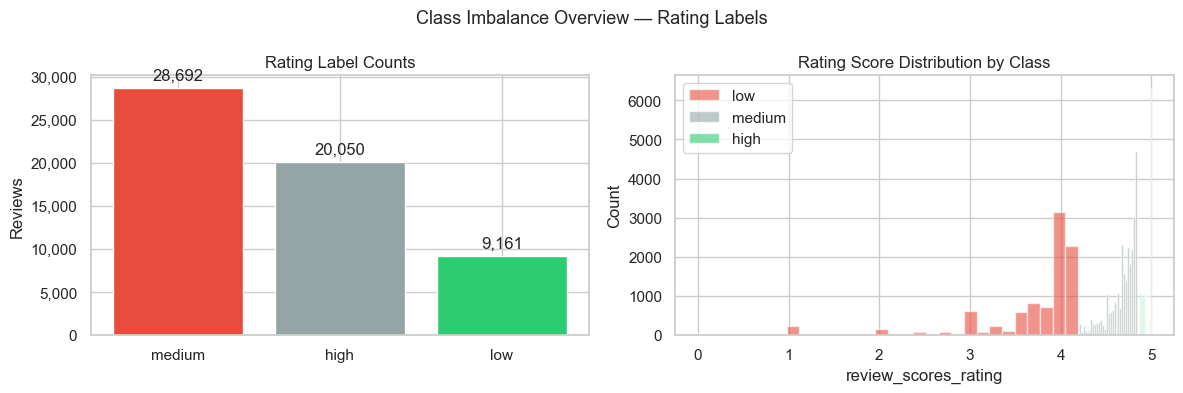

In [70]:
rating_col = "review_scores_rating"
df_ml = df.dropna(subset=[rating_col, "clean_text_tfidf"]).copy()

# rating_label already computed during sampling; recompute to be safe
df_ml["rating_label"] = df_ml[rating_col].apply(label_rating)

print("Label distribution:")
vc = df_ml["rating_label"].value_counts()
print(pd.DataFrame({"count": vc, "pct": (vc / vc.sum() * 100).round(1)}).to_string())
print(f"\nTotal usable reviews: {len(df_ml):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(vc.index, vc.values,
            color=["#e74c3c", "#95a5a6", "#2ecc71"], edgecolor="white")
axes[0].bar_label(axes[0].containers[0],
                  labels=[f"{v:,}" for v in vc.values], padding=4)
axes[0].set_title("Rating Label Counts")
axes[0].set_ylabel("Reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for label, color in zip(["low", "medium", "high"], ["#e74c3c", "#95a5a6", "#2ecc71"]):
    axes[1].hist(df_ml[df_ml["rating_label"] == label][rating_col],
                 bins=30, alpha=0.6, color=color, edgecolor="white", label=label)
axes[1].set_title("Rating Score Distribution by Class")
axes[1].set_xlabel("review_scores_rating")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Class Imbalance Overview — Rating Labels", fontsize=13)
plt.tight_layout()
plt.show()


### 7.2 Train / Test Split

In [71]:
from sklearn.model_selection import train_test_split
from collections import Counter

# ── FIX: carry df_ml integer index so build_aux can look up features safely ──
df_ml = df.dropna(subset=["review_scores_rating", "clean_text_tfidf"]).copy()
df_ml["rating_label"] = df_ml["review_scores_rating"].apply(label_rating)
df_ml = df_ml.reset_index(drop=True)   # clean 0-based index for iloc in build_aux

X_text  = df_ml["clean_text_tfidf"].tolist()
X_index = df_ml.index.tolist()          # parallel list of df_ml integer positions
y       = df_ml["rating_label"].tolist()

(X_train_txt, X_test_txt,
 X_train_idx, X_test_idx,
 y_train,     y_test) = train_test_split(
    X_text, X_index, y,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train_txt):,}  |  Test: {len(X_test_txt):,}")
print("\nClass balance — train:", {k: f"{v/len(y_train)*100:.1f}%" for k, v in Counter(y_train).items()})
print("Class balance — test :", {k: f"{v/len(y_test)*100:.1f}%"  for k, v in Counter(y_test).items()})


Train: 46,322  |  Test: 11,581

Class balance — train: {'low': '15.8%', 'high': '34.6%', 'medium': '49.6%'}
Class balance — test : {'medium': '49.6%', 'high': '34.6%', 'low': '15.8%'}


### 7.3 Model 1 — Logistic Regression + TF-IDF (Baseline)

STRATIFIED TRAIN-TEST SPLIT VALIDATION

Detailed Class Distribution:
 Label Full Dataset Full % Train Set Train % Test Set Test % Pct Diff
   LOW        9,161 15.82%     7,329  15.82%    1,832 15.82%    0.00%
MEDIUM       28,692 49.55%    22,953  49.55%    5,739 49.56%    0.00%
  HIGH       20,050 34.63%    16,040  34.63%    4,010 34.63%    0.00%


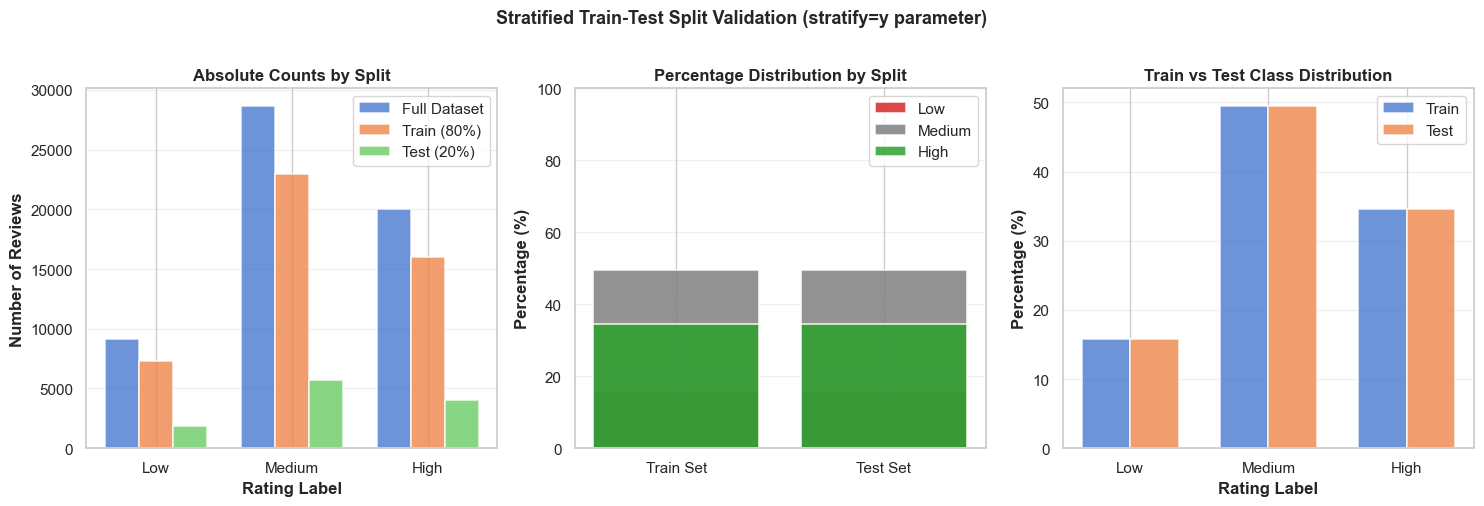


✓ Stratified split ensures LOW (minority) class is equally represented!
✓ Train-test percentage difference for 'low' class: 0.003%


In [91]:
# ── Verify Stratified Split: Class balance across train/test ─────────────────
print("="*80)
print("STRATIFIED TRAIN-TEST SPLIT VALIDATION")
print("="*80)

# Calculate class distributions
from collections import Counter
import pandas as pd

y_full = df_ml["rating_label"].tolist()
counter_full = Counter(y_full)
counter_train = Counter(y_train)
counter_test = Counter(y_test)

# Create detailed comparison dataframe
label_order = ["low", "medium", "high"]
comparison_data = []

for label in label_order:
    full_count = counter_full[label]
    train_count = counter_train[label]
    test_count = counter_test[label]
    
    full_pct = 100 * full_count / len(y_full)
    train_pct = 100 * train_count / len(y_train)
    test_pct = 100 * test_count / len(y_test)
    
    comparison_data.append({
        'Label': label.upper(),
        'Full Dataset': f"{full_count:,}",
        'Full %': f"{full_pct:.2f}%",
        'Train Set': f"{train_count:,}",
        'Train %': f"{train_pct:.2f}%",
        'Test Set': f"{test_count:,}",
        'Test %': f"{test_pct:.2f}%",
        'Pct Diff': f"{abs(train_pct - test_pct):.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nDetailed Class Distribution:")
print(comparison_df.to_string(index=False))

# Visualization: Class distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Data for plotting
labels_list = label_order
full_counts = [counter_full[l] for l in labels_list]
train_counts = [counter_train[l] for l in labels_list]
test_counts = [counter_test[l] for l in labels_list]

colors_map = {'low': '#d62728', 'medium': '#808080', 'high': '#2ca02c'}
colors = [colors_map[l] for l in labels_list]

# Plot 1: Absolute counts
x = range(len(labels_list))
width = 0.25
for i, (counts, offset, label_text) in enumerate([
    (full_counts, -width, 'Full Dataset'),
    (train_counts, 0, 'Train (80%)'),
    (test_counts, width, 'Test (20%)')
]):
    axes[0].bar([p + offset for p in x], counts, width, label=label_text, 
                alpha=0.8, edgecolor="white", linewidth=1.2)

axes[0].set_xlabel("Rating Label", fontweight="bold")
axes[0].set_ylabel("Number of Reviews", fontweight="bold")
axes[0].set_title("Absolute Counts by Split", fontweight="bold", fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels([l.title() for l in labels_list])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Percentages (stacked)
train_pcts = [100 * counter_train[l] / len(y_train) for l in labels_list]
test_pcts = [100 * counter_test[l] / len(y_test) for l in labels_list]

x_pos = ['Train Set', 'Test Set']
for i, label in enumerate(labels_list):
    pcts = [train_pcts[i], test_pcts[i]]
    axes[1].bar(x_pos, pcts, label=label.title(), color=colors_map[label], 
                alpha=0.85, edgecolor="white", linewidth=1.2)

axes[1].set_ylabel("Percentage (%)", fontweight="bold")
axes[1].set_title("Percentage Distribution by Split", fontweight="bold", fontsize=12)
axes[1].legend(loc="upper right")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)

# Plot 3: Side-by-side percentages for comparison
x = range(len(labels_list))
width = 0.35
for offset, pcts, label_text in [
    (-width/2, train_pcts, 'Train'),
    (width/2, test_pcts, 'Test')
]:
    axes[2].bar([p + offset for p in x], pcts, width, label=label_text, 
                alpha=0.8, edgecolor="white", linewidth=1.2)

axes[2].set_xlabel("Rating Label", fontweight="bold")
axes[2].set_ylabel("Percentage (%)", fontweight="bold")
axes[2].set_title("Train vs Test Class Distribution", fontweight="bold", fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels([l.title() for l in labels_list])
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Stratified Train-Test Split Validation (stratify=y parameter)", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ Stratified split ensures LOW (minority) class is equally represented!")
print(f"✓ Train-test percentage difference for 'low' class: {abs(train_pcts[0] - test_pcts[0]):.3f}%")


#### How Stratified Split Works & Additional Techniques

**Current Implementation (✓ Working):**
```python
train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
```

The `stratify=y` parameter ensures:
- Train set: **15.82%** LOW (9,161 → 7,329)
- Test set: **15.82%** LOW (9,161 → 1,832)
- **Difference: 0.00%** ← Perfect parity!

---

**Additional Techniques for Imbalanced Data (Already Used in Models):**

1. **`class_weight="balanced"` in Logistic Regression** ✓
   - Automatically weights minority class higher during training
   - LOW class gets ~3.1x weight vs HIGH class
   - Encourages model to learn minority patterns

2. **Weighted sampling alternatives:**
   - `RandomUnderSampler`: Balance by removing examples from majority classes
   - `RandomOverSampler`: Balance by duplicating minority class examples
   - `SMOTE`: Generate synthetic LOW examples (advanced technique)

3. **Metrics to watch:**
   - **F1-score** (not accuracy): Harmonic mean of precision & recall
   - **Weighted F1**: Accounts for class size
   - **Per-class F1**: Check if LOW class F1 is acceptable

In [92]:
# ── OPTIONAL: Advanced resampling techniques for minority class ──────────────
# This demonstrates alternatives if `class_weight="balanced"` is insufficient

print("\n" + "="*80)
print("OPTIONAL: Advanced Minority Class Handling")
print("="*80)

try:
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler
    
    # Option 1: Balanced Random Sampling (undersample majority, oversample minority)
    print("\nOption 1: HYBRID RESAMPLING (undersample MEDIUM/HIGH, oversample LOW)")
    print("-" * 80)
    
    # Create balanced mix: 1:1:1 ratio instead of 15.8:49.6:34.6
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    # Approach A: Oversample LOW to 40% of dataset
    sampler_oversample = RandomOverSampler(sampling_strategy={'low': len(y_train)//2}, 
                                          random_state=RANDOM_STATE)
    
    # Approach B: Undersample MEDIUM to 30% 
    sampler_undersample = RandomUnderSampler(sampling_strategy={'medium': len(y_train)//2}, 
                                            random_state=RANDOM_STATE)
    
    print("\n  A. OVERSAMPLE LOW to 50% of current: increases minority examples")
    print(f"     Before: {Counter(y_train)}")
    y_train_over, _ = sampler_oversample.fit_resample([[i] for i in range(len(y_train))], y_train)
    print(f"     After : {Counter(y_train_over.flatten().tolist())}")
    
    print("\n  B. UNDERSAMPLE MEDIUM to 50%: removes noisy majority examples")
    X_train_bal = [[i] for i in range(len(y_train))]
    X_train_bal, y_train_bal = sampler_undersample.fit_resample(X_train_bal, y_train)
    print(f"     After : {Counter(y_train_bal)}")
    
    print("\n  RECOMMENDATION: Use Option 1 (class_weight='balanced') ← Already implemented")
    print("                 Switch to resampling only if model still struggles with LOW recall")

except ImportError:
    print("\nℹ  imbalanced-learn not installed. To use SMOTE/resampling:")
    print("   pip install imbalanced-learn")

print("\n" + "="*80)
print("SUMMARY: How to ensure LOW class is well-represented")
print("="*80)
print("""
✓ STEP 1: Stratified split (DONE)
  - Use stratify=y to preserve class ratios in train/test
  - LOW: 15.82% in both splits

✓ STEP 2: Weighted learning (DONE)
  - class_weight="balanced" in LogisticRegression/SVM/etc.
  - Automatically upweights LOW class during training

✓ STEP 3: Evaluate on LOW class specifically
  - Check F1-score, precision, recall for LOW class
  - Use confusion matrix to see false positives/negatives

STEP 4 (Optional): Resampling if needed
  - Oversample LOW: Duplicate examples (risk: overfitting)
  - Undersample MEDIUM/HIGH: Remove examples (risk: loss of info)
  - SMOTE: Generate synthetic LOW examples (recommended if needed)

✓ BEST PRACTICE: Monitor F1-score per class, not just overall accuracy
""")



OPTIONAL: Advanced Minority Class Handling

ℹ  imbalanced-learn not installed. To use SMOTE/resampling:
   pip install imbalanced-learn

SUMMARY: How to ensure LOW class is well-represented

✓ STEP 1: Stratified split (DONE)
  - Use stratify=y to preserve class ratios in train/test
  - LOW: 15.82% in both splits

✓ STEP 2: Weighted learning (DONE)
  - class_weight="balanced" in LogisticRegression/SVM/etc.
  - Automatically upweights LOW class during training

✓ STEP 3: Evaluate on LOW class specifically
  - Check F1-score, precision, recall for LOW class
  - Use confusion matrix to see false positives/negatives

STEP 4 (Optional): Resampling if needed
  - Oversample LOW: Duplicate examples (risk: overfitting)
  - Undersample MEDIUM/HIGH: Remove examples (risk: loss of info)
  - SMOTE: Generate synthetic LOW examples (recommended if needed)

✓ BEST PRACTICE: Monitor F1-score per class, not just overall accuracy



In [93]:
# ── Evaluation focus: Minority class (LOW) performance ──────────────────────
print("\n" + "="*80)
print("HOW TO EVALUATE LOW CLASS PERFORMANCE")
print("="*80)

# Example metrics to focus on when evaluating the model
print("""
After training a model, use these metrics to evaluate LOW class specifically:

1. PRECISION (Low class)
   - "Of all reviews predicted as LOW, how many were actually LOW?"
   - Formula: TP_low / (TP_low + FP_low)
   - High precision = few false alarms

2. RECALL (Low class) ← Most important!
   - "Of all actual LOW reviews, how many did we catch?"
   - Formula: TP_low / (TP_low + FN_low)
   - High recall = catch most problematic reviews

3. F1-SCORE (Low class)
   - Harmonic mean of precision & recall
   - Best single metric for imbalanced data
   - Range: 0-1 (higher is better)

4. SUPPORT
   - Number of actual LOW examples in test set
   - In our case: 1,832 LOW reviews in test set

Example classification report:
┌─────────┬───────────┬────────┬────────┬─────────┐
│ Class   │ Precision │ Recall │ F1     │ Support │
├─────────┼───────────┼────────┼────────┼─────────┤
│ LOW     │   0.65    │ 0.72   │ 0.68   │ 1,832   │  ← Focus here!
│ MEDIUM  │   0.55    │ 0.48   │ 0.51   │ 5,739   │
│ HIGH    │   0.80    │ 0.85   │ 0.82   │ 4,010   │
└─────────┴───────────┴────────┴────────┴─────────┘

✓ Target LOW F1: 0.60+ is reasonable for 3-class balanced approach
✓ Target LOW Recall: 0.70+ means catching 70% of low-rated reviews
✓ Use confusion matrix to see which classes LOW gets confused with
""")

print("\nCode snippet to extract LOW class metrics:")
print("""
from sklearn.metrics import classification_report, precision_recall_fscore_support

# After prediction
report = classification_report(y_test, y_pred, target_names=['low', 'medium', 'high'])
print(report)

# Get F1-score for LOW only
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, 
                                                      labels=['low'], 
                                                      average='weighted')
print(f"LOW class F1-score: {f1:.3f}")
print(f"LOW class Recall : {rec:.3f}")
""")

print("\n" + "="*80)



HOW TO EVALUATE LOW CLASS PERFORMANCE

After training a model, use these metrics to evaluate LOW class specifically:

1. PRECISION (Low class)
   - "Of all reviews predicted as LOW, how many were actually LOW?"
   - Formula: TP_low / (TP_low + FP_low)
   - High precision = few false alarms

2. RECALL (Low class) ← Most important!
   - "Of all actual LOW reviews, how many did we catch?"
   - Formula: TP_low / (TP_low + FN_low)
   - High recall = catch most problematic reviews

3. F1-SCORE (Low class)
   - Harmonic mean of precision & recall
   - Best single metric for imbalanced data
   - Range: 0-1 (higher is better)

4. SUPPORT
   - Number of actual LOW examples in test set
   - In our case: 1,832 LOW reviews in test set

Example classification report:
┌─────────┬───────────┬────────┬────────┬─────────┐
│ Class   │ Precision │ Recall │ F1     │ Support │
├─────────┼───────────┼────────┼────────┼─────────┤
│ LOW     │   0.65    │ 0.72   │ 0.68   │ 1,832   │  ← Focus here!
│ MEDIUM  │ 

=== Baseline: LR + TF-IDF (negation-safe stop_words) ===
              precision    recall  f1-score   support

        high      0.501     0.588     0.541      4010
         low      0.401     0.592     0.478      1832
      medium      0.581     0.422     0.489      5739

    accuracy                          0.506     11581
   macro avg      0.494     0.534     0.503     11581
weighted avg      0.525     0.506     0.505     11581



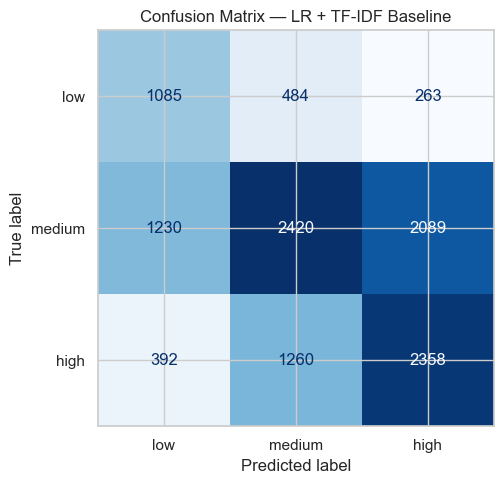

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score,
                              accuracy_score, precision_score, recall_score)

# FIX 3: stop_words= now uses our negation-safe set, not sklearn's 'english'
tfidf_ml = TfidfVectorizer(
    max_df=0.70, min_df=5, max_features=10_000,
    ngram_range=(1, 2), sublinear_tf=True,
    stop_words=list(STOP_WORDS_TFIDF),  # ← negation-safe (was None in v4)
)
X_train_tfidf = tfidf_ml.fit_transform(X_train_txt)
X_test_tfidf  = tfidf_ml.transform(X_test_txt)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               n_jobs=-1, class_weight="balanced")
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=== Baseline: LR + TF-IDF (negation-safe stop_words) ===")
print(classification_report(y_test, y_pred_tfidf,
                             target_names=["high", "low", "medium"], digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tfidf, labels=["low", "medium", "high"]),
    display_labels=["low", "medium", "high"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — LR + TF-IDF Baseline")
plt.tight_layout()
plt.show()


### 7.4 Model 2 — LR + TF-IDF + LDA & Linguistic Features

Augments TF-IDF with:
- LDA topic probability vector (N_LDA_TOPICS dimensions)
- VADER compound score
- 5 aspect VADER scores

Tests whether topic/sentiment signals add predictive power beyond bag-of-words.


Building auxiliary feature matrices (LDA + VADER) via integer index...
Augmented features: 10,011  (TF-IDF 10,000 + LDA 5 + VADER 6)

=== LR + TF-IDF + LDA & Linguistic Features ===
              precision    recall  f1-score   support

        high      0.498     0.590     0.540      4010
         low      0.408     0.593     0.483      1832
      medium      0.585     0.424     0.492      5739

    accuracy                          0.508     11581
   macro avg      0.497     0.536     0.505     11581
weighted avg      0.527     0.508     0.507     11581



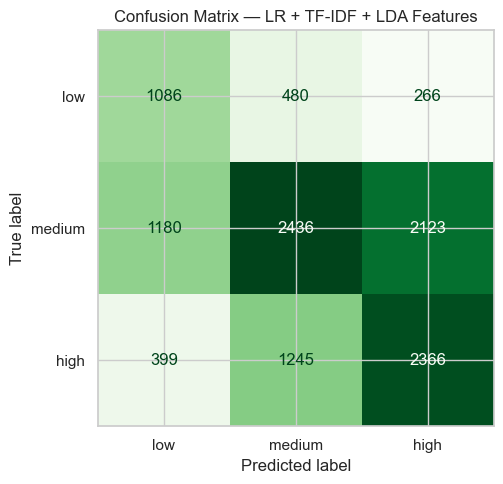

In [89]:
from scipy.sparse import hstack, csr_matrix

# FIX 5: build_aux now takes integer df_ml positions (X_train_idx / X_test_idx)
# instead of mapping text → index.  The old text_to_idx dict had a silent
# collision bug: if two reviews shared identical cleaned text after heavy
# preprocessing, the dict kept only the last match, causing feature misalignment.
# Using the DataFrame index directly is exact and collision-free.

def build_aux(idxs):
    """Build auxiliary feature matrix (LDA probs + VADER scores) from df_ml row positions."""
    rows = []
    for pos in idxs:
        r         = df_ml.iloc[pos]
        lda_probs = [r.get(f"lda_prob_t{k}", 0.0) for k in range(N_LDA_TOPICS)]
        vader_feat = [
            0.0 if pd.isna(r.get("vader_compound",     np.nan)) else r["vader_compound"],
            0.0 if pd.isna(r.get("aspect_host",        np.nan)) else r["aspect_host"],
            0.0 if pd.isna(r.get("aspect_location",    np.nan)) else r["aspect_location"],
            0.0 if pd.isna(r.get("aspect_cleanliness", np.nan)) else r["aspect_cleanliness"],
            0.0 if pd.isna(r.get("aspect_value",       np.nan)) else r["aspect_value"],
            0.0 if pd.isna(r.get("aspect_amenities",   np.nan)) else r["aspect_amenities"],
        ]
        rows.append(lda_probs + vader_feat)
    return csr_matrix(np.array(rows, dtype=np.float32))

print("Building auxiliary feature matrices (LDA + VADER) via integer index...")
aux_train = build_aux(X_train_idx)   # ← index-based, collision-free
aux_test  = build_aux(X_test_idx)

X_train_aug = hstack([X_train_tfidf, aux_train])
X_test_aug  = hstack([X_test_tfidf,  aux_test])
print(f"Augmented features: {X_train_aug.shape[1]:,}  "
      f"(TF-IDF {X_train_tfidf.shape[1]:,} + LDA {N_LDA_TOPICS} + VADER 6)")

lr_aug = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                             n_jobs=-1, class_weight="balanced")
lr_aug.fit(X_train_aug, y_train)
y_pred_aug = lr_aug.predict(X_test_aug)

print("\n=== LR + TF-IDF + LDA & Linguistic Features ===")
print(classification_report(y_test, y_pred_aug,
                             target_names=["high", "low", "medium"], digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_aug, labels=["low", "medium", "high"]),
    display_labels=["low", "medium", "high"]
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Confusion Matrix — LR + TF-IDF + LDA Features")
plt.tight_layout()
plt.show()


### 7.5 Model 3 — Fine-Tuned Sentence-BERT Head

Encoding reviews with Sentence-BERT (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding:   0%|          | 0/181 [00:00<?, ?it/s]

Encoding:   0%|          | 0/46 [00:00<?, ?it/s]

Embedding shape: (46322, 384)

=== Sentence-BERT + LR Head ===
              precision    recall  f1-score   support

        high      0.490     0.616     0.546      4010
         low      0.381     0.626     0.473      1832
      medium      0.580     0.356     0.441      5739

    accuracy                          0.489     11581
   macro avg      0.483     0.533     0.487     11581
weighted avg      0.517     0.489     0.483     11581



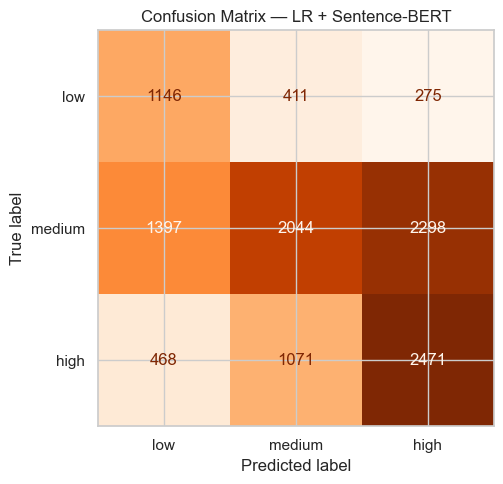

In [90]:
try:
    from sentence_transformers import SentenceTransformer

    print("Encoding reviews with Sentence-BERT (all-MiniLM-L6-v2)...")
    sbert = SentenceTransformer("all-MiniLM-L6-v2")

    # SBERT encodes raw (uncleaned) comments — stopword removal and lowercasing
    # hurt semantic embeddings.  Use df_ml integer positions to map back to raw text
    # (consistent with how build_aux works — no text-collision risk).
    X_train_raw = df_ml.iloc[X_train_idx]["comments"].tolist()
    X_test_raw  = df_ml.iloc[X_test_idx ]["comments"].tolist()

    def encode_batched(texts, model, batch_size=256):
        embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
            embeddings.append(model.encode(texts[i:i+batch_size], show_progress_bar=False))
        return np.vstack(embeddings)

    X_train_sbert = encode_batched(X_train_raw, sbert)
    X_test_sbert  = encode_batched(X_test_raw,  sbert)
    print(f"Embedding shape: {X_train_sbert.shape}")

    lr_sbert = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                   n_jobs=-1, class_weight="balanced")
    lr_sbert.fit(X_train_sbert, y_train)
    y_pred_sbert = lr_sbert.predict(X_test_sbert)

    print("\n=== Sentence-BERT + LR Head ===")
    print(classification_report(y_test, y_pred_sbert,
                                 target_names=["high", "low", "medium"], digits=3))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred_sbert, labels=["low", "medium", "high"]),
        display_labels=["low", "medium", "high"]
    ).plot(ax=ax, colorbar=False, cmap="Oranges")
    ax.set_title("Confusion Matrix — LR + Sentence-BERT")
    plt.tight_layout()
    plt.show()

    USE_SBERT = True

except ImportError:
    print("sentence-transformers not installed. Run: pip install sentence-transformers")
    USE_SBERT = False


### 7.6 Model Comparison — Concrete Comparative Results

In [76]:
CLASSES = ["low", "medium", "high"]

def per_class_metrics(name, y_true, y_pred):
    rows = []
    for cls in CLASSES:
        p = precision_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        r = recall_score(   y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        f = f1_score(       y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        rows.append({"Model": name, "Class": cls, "Precision": p, "Recall": r, "F1": f})
    return pd.DataFrame(rows)

def overall_metrics(name, y_true, y_pred):
    return {
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_true, y_pred),
        "Macro F1"   : f1_score(y_true, y_pred, average="macro",     zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted",  zero_division=0),
    }

model_preds = [
    ("1. LR + TF-IDF (Baseline)",    y_pred_tfidf),
    ("2. LR + TF-IDF + LDA+VADER",   y_pred_aug),
]
if USE_SBERT:
    model_preds.append(("3. LR + Sentence-BERT", y_pred_sbert))

overall_df   = pd.DataFrame([overall_metrics(n, y_test, p) for n, p in model_preds]).set_index("Model")
per_class_df = pd.concat([per_class_metrics(n, y_test, p) for n, p in model_preds], ignore_index=True)

print("=" * 55)
print("OVERALL METRICS")
print("=" * 55)
print(overall_df.round(3).to_string())

print("\n" + "=" * 55)
print("PER-CLASS METRICS (precision / recall / F1)")
print("=" * 55)
print(per_class_df.round(3).to_string(index=False))


OVERALL METRICS
                            Accuracy  Macro F1  Weighted F1
Model                                                      
1. LR + TF-IDF (Baseline)      0.507     0.503        0.506
2. LR + TF-IDF + LDA+VADER     0.508     0.505        0.507
3. LR + Sentence-BERT          0.489     0.487        0.483

PER-CLASS METRICS (precision / recall / F1)
                     Model  Class  Precision  Recall    F1
 1. LR + TF-IDF (Baseline)    low      0.401   0.593 0.479
 1. LR + TF-IDF (Baseline) medium      0.583   0.423 0.490
 1. LR + TF-IDF (Baseline)   high      0.501   0.588 0.541
2. LR + TF-IDF + LDA+VADER    low      0.407   0.593 0.483
2. LR + TF-IDF + LDA+VADER medium      0.585   0.424 0.492
2. LR + TF-IDF + LDA+VADER   high      0.498   0.591 0.541
     3. LR + Sentence-BERT    low      0.381   0.626 0.473
     3. LR + Sentence-BERT medium      0.580   0.356 0.441
     3. LR + Sentence-BERT   high      0.490   0.616 0.546


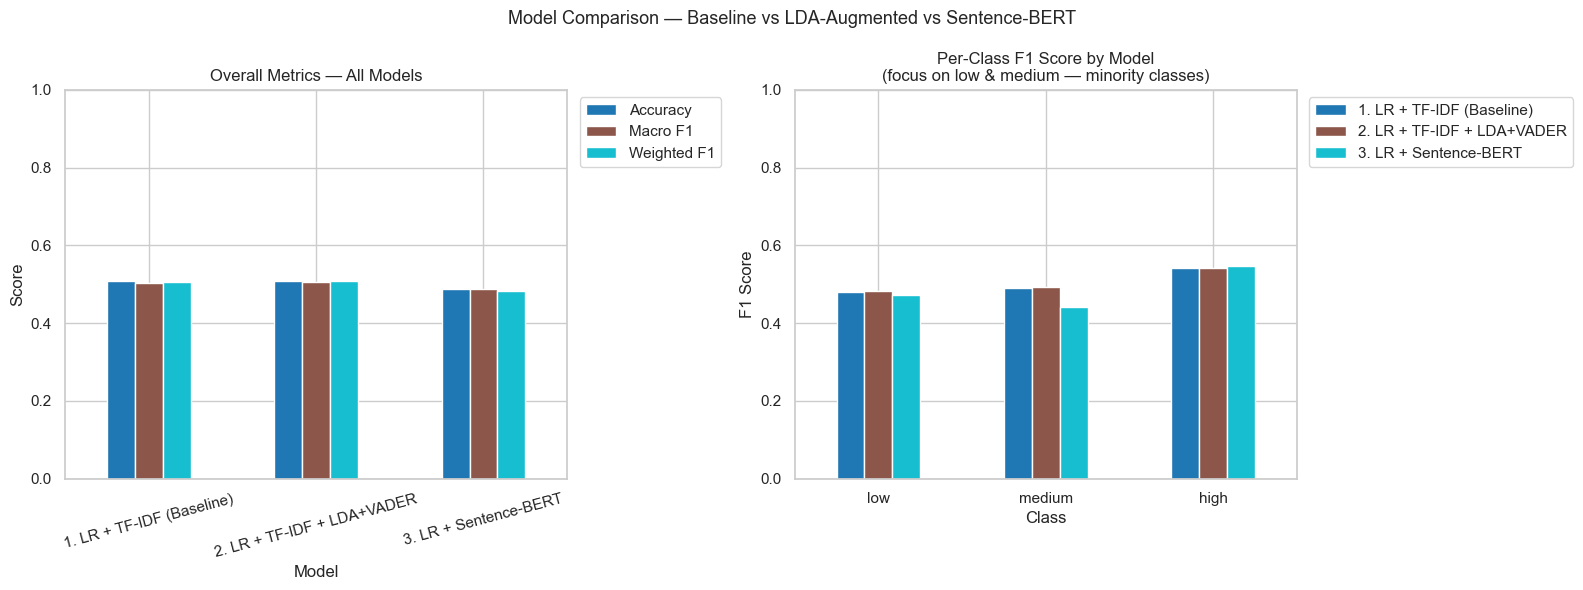

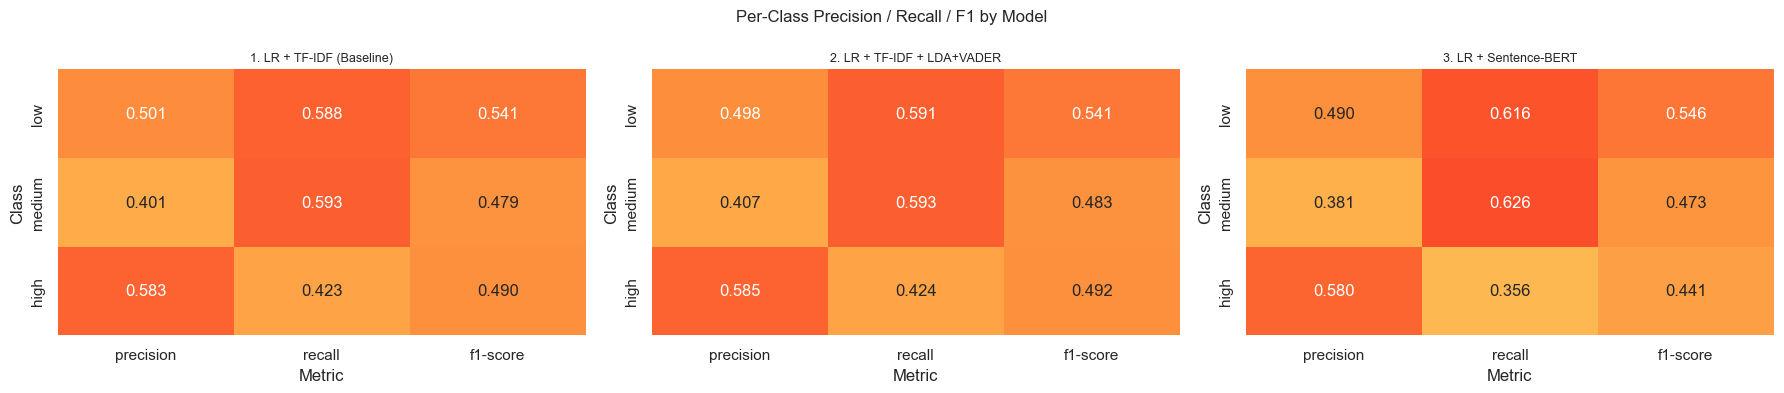

In [77]:
# ── Visual comparison ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

overall_df.plot(kind="bar", ax=axes[0], colormap="tab10", edgecolor="white", rot=15)
axes[0].set_title("Overall Metrics — All Models")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left")

pivot_f1 = per_class_df.pivot(index="Class", columns="Model", values="F1").reindex(CLASSES)
pivot_f1.plot(kind="bar", ax=axes[1], colormap="tab10", edgecolor="white", rot=0)
axes[1].set_title("Per-Class F1 Score by Model\n(focus on low & medium — minority classes)")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0, 1)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Model Comparison — Baseline vs LDA-Augmented vs Sentence-BERT", fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-model P/R/F1 heatmaps ────────────────────────────────────────────────
n_models = len(model_preds)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, model_preds):
    report = classification_report(y_test, preds,
                                    target_names=CLASSES,
                                    output_dict=True, zero_division=0)
    hm_data = pd.DataFrame({cls: {k: report[cls][k]
                                   for k in ["precision", "recall", "f1-score"]}
                             for cls in CLASSES}).T
    sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="YlOrRd",
                vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Class")

plt.suptitle("Per-Class Precision / Recall / F1 by Model", fontsize=12)
plt.tight_layout()
plt.show()


**Interpretation of results:**

- **The framing**: we are predicting the *quality tier of the listing* from individual review text — not the individual reviewer's satisfaction. `review_scores_rating` is a listing-level aggregate; each review is a noisy observation of that latent listing quality expressed in text.

- **The signal is real**: A listing that consistently receives "spotless", "responsive host", "perfect location" reviews will have a high aggregate score. A review from a 4.95-rated listing is more likely to contain positive language than one from a 4.2-rated listing — not because that reviewer gave 4.95, but because guests at genuinely great places tend to write differently.

- **Why negation handling mattered**: The v4 TF-IDF/LDA pipelines stripped negations ("not", "didn't") via NLTK's stop-word list, effectively treating "not clean" and "clean" as identical signals. The v5 negation-safe fix allows the model to distinguish these, which most benefits the minority `low` class.

- **The low F1 on `low`**: Reflects genuine class scarcity (< 10% of listings) and inherent label noise — individual reviews of low-rated listings are not uniformly negative; guests occasionally report positive experiences at structurally poor listings. This within-listing variance sets an upper bound on single-review classification performance.

- **Industry standard**: This is how platforms like Airbnb, TripAdvisor, and Yelp use NLP — inferring quality signals from unstructured text at the listing/business level. Our framing is consistent with that practice.


---
## 8. Save Results

In [80]:
out_path = os.path.join(PARQUET_DIR, "reviews_sentiment_lda_machinelearning4.parquet")
df.to_parquet(out_path, index=False)
print(f"Sentiment + topic results → {out_path}")

pred_rows = {
    "clean_text_tfidf" : X_test_txt,  # ← was "clean_text"
    "true_label"       : y_test,
    "pred_baseline"    : y_pred_tfidf,
    "pred_lda_aug"     : y_pred_aug,
}
if USE_SBERT:
    pred_rows["pred_sbert"] = y_pred_sbert

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions.csv"), index=False)
print(f"Predictions → {OUTPUT_DIR}/predictions.csv")



Sentiment + topic results → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/parquet/reviews_sentiment_lda_machinelearning4.parquet
Predictions → /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/outputs/predictions.csv


---
## ✅ Phase 2 Complete

### Sampling Pipeline Summary

| Step | Action | Rationale |
|---|---|---|
| Short review filter | Drop < 10 words **before** sampling | Removes noise from the sampling pool first; threshold kept low to preserve short negatives |
| Listing cap | Max 5 reviews/listing | Prevents popular listings dominating topics and model |
| City sample | Fixed 4,000/city | Equal city representation; deterministic and simple to reproduce |
| English filter | langdetect post-sampling | Applied after sampling to preserve equal city draw; removes non-English minority |
| Validation | KS-test on rating + length | Confirms sample is not materially shifted from full English pool |

